In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

In [ ]:
DATA_DIR = "./"

train = pd.read_csv(f"{DATA_DIR}/train.csv")

In [ ]:
train["sale_date"] = pd.to_datetime(train["sale_date"])

train["datetime"] = (
    train["sale_date"] +
    pd.to_timedelta(train["sale_hour"], unit="h")
)

train["year"] = train["sale_date"].dt.year
train["month"] = train["sale_date"].dt.month
train["day"] = train["sale_date"].dt.day
train["weekday"] = train["sale_date"].dt.weekday
train["weekday_name"] = train["sale_date"].dt.day_name()
train["is_weekend"] = train["weekday"].isin([5, 6]).astype(int)

In [ ]:
train

,sale_date,sale_hour,guests_count,datetime,year,month,day,weekday,weekday_name,is_weekend
0,2019-01-02,7,5,2019-01-02 07:00:00,2019,1,2,2,Wednesday,0
1,2019-01-02,8,11,2019-01-02 08:00:00,2019,1,2,2,Wednesday,0
2,2019-01-02,9,14,2019-01-02 09:00:00,2019,1,2,2,Wednesday,0
3,2019-01-02,10,17,2019-01-02 10:00:00,2019,1,2,2,Wednesday,0
4,2019-01-02,11,28,2019-01-02 11:00:00,2019,1,2,2,Wednesday,0
...,...,...,...,...,...,...,...,...,...,...
40538,2026-04-26,18,127,2026-04-26 18:00:00,2026,4,26,6,Sunday,1
40539,2026-04-26,19,128,2026-04-26 19:00:00,2026,4,26,6,Sunday,1
40540,2026-04-26,20,100,2026-04-26 20:00:00,2026,4,26,6,Sunday,1
40541,2026-04-26,21,70,2026-04-26 21:00:00,2026,4,26,6,Sunday,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка синей цветовой схемы по умолчанию
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1f77b4', '#4a9fd8', '#6ab0de', '#8bc4e8', '#aed6f1'])
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#1f77b4'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.color'] = '#cccccc'

# (Опционально) Настройка Seaborn для синей темы
sns.set_style("whitegrid")
sns.set_palette(["#1f77b4", "#4a9fd8", "#6ab0de", "#8bc4e8"])

print("✅ Графики теперь синие по умолчанию")

✅ Графики теперь синие по умолчанию


## EDA

In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

первичный обзор

In [ ]:
datasets = {
    "train": train,
    "reqlabor": reqlabor,
    "sched": sched,
    "station_priorities": station_priorities,
    "shifts": shifts,
    "staff_limits": staff_limits
}

for name, df in datasets.items():
    print("="*60)
    print(name.upper())
    print("="*60)

    print("\nSHAPE:")
    print(df.shape)

    print("\nDTYPES:")
    print(df.dtypes)

    print("\nHEAD:")
    print(df.head())

    print("\nMISSING VALUES:")
    print(df.isna().sum())

    print("\nDUPLICATES:", df.duplicated().sum())

    print("\n")

TRAIN

SHAPE:
(40543, 3)

DTYPES:
sale_date       object
sale_hour        int64
guests_count     int64
dtype: object

HEAD:
    sale_date  sale_hour  guests_count
0  2019-01-02          7             5
1  2019-01-02          8            11
2  2019-01-02          9            14
3  2019-01-02         10            17
4  2019-01-02         11            28

MISSING VALUES:
sale_date       0
sale_hour       0
guests_count    0
dtype: int64

DUPLICATES: 0


REQLABOR

SHAPE:
(139, 4)

DTYPES:
station_key     object
version         object
guests_count     int64
reqlabor         int64
dtype: object

HEAD:
  station_key     version  guests_count  reqlabor
0         BVR  будни/осн.           229         1
1         BVR  будни/осн.           375         2
2         BVR  будни/осн.           425         3
3           C  будни/осн.            36         1
4           C  будни/осн.           102         2

MISSING VALUES:
station_key     0
version         0
guests_count    0
reqlabor        0
dtyp

In [ ]:
train["sale_date"] = pd.to_datetime(train["sale_date"])

train["datetime"] = (
    train["sale_date"] +
    pd.to_timedelta(train["sale_hour"], unit="h")
)

train["year"] = train["sale_date"].dt.year
train["month"] = train["sale_date"].dt.month
train["day"] = train["sale_date"].dt.day
train["weekday"] = train["sale_date"].dt.weekday
train["weekday_name"] = train["sale_date"].dt.day_name()
train["is_weekend"] = train["weekday"].isin([5, 6]).astype(int)

Базовая статистика guests_count

In [ ]:
print(train["guests_count"].describe())

count    40543.000000
mean       103.789729
std         45.204182
min          1.000000
25%         70.000000
50%        101.000000
75%        135.000000
max        299.000000
Name: guests_count, dtype: float64


Распределение числа гостей

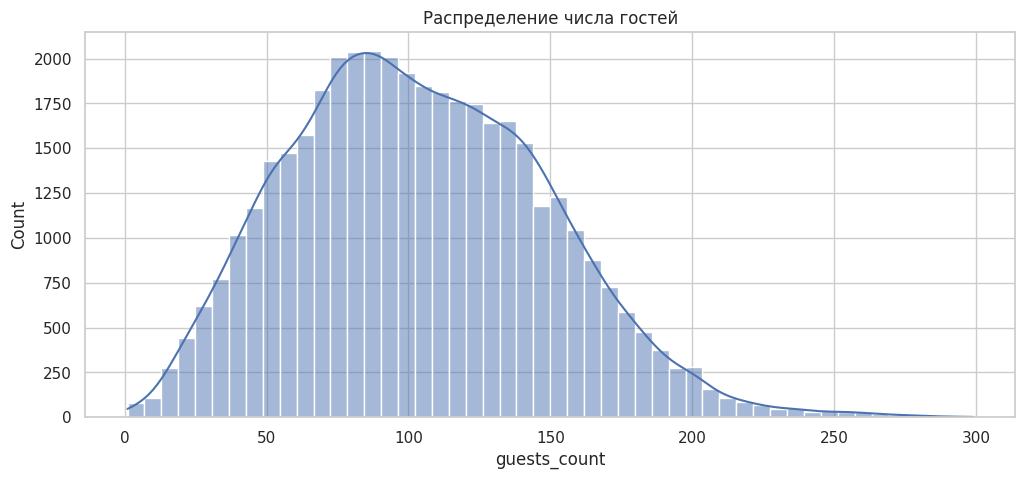

In [ ]:
plt.figure(figsize=(12, 5))
sns.histplot(train["guests_count"], bins=50, kde=True)
plt.title("Распределение числа гостей")
plt.xlabel("guests_count")
plt.show()

Временной ряд

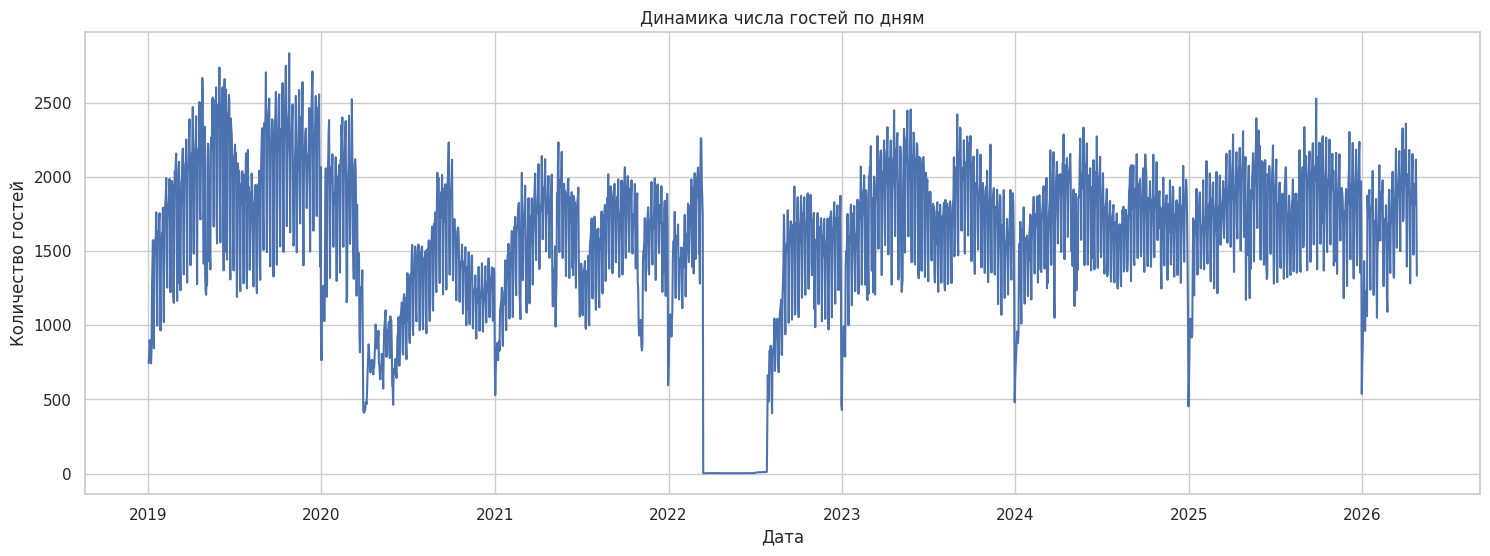

In [ ]:

daily_guests = (
    train.groupby("sale_date")["guests_count"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(18, 6))
plt.plot(daily_guests["sale_date"], daily_guests["guests_count"])
plt.title("Динамика числа гостей по дням")
plt.xlabel("Дата")
plt.ylabel("Количество гостей")
plt.show()

Среднее число гостей по часам

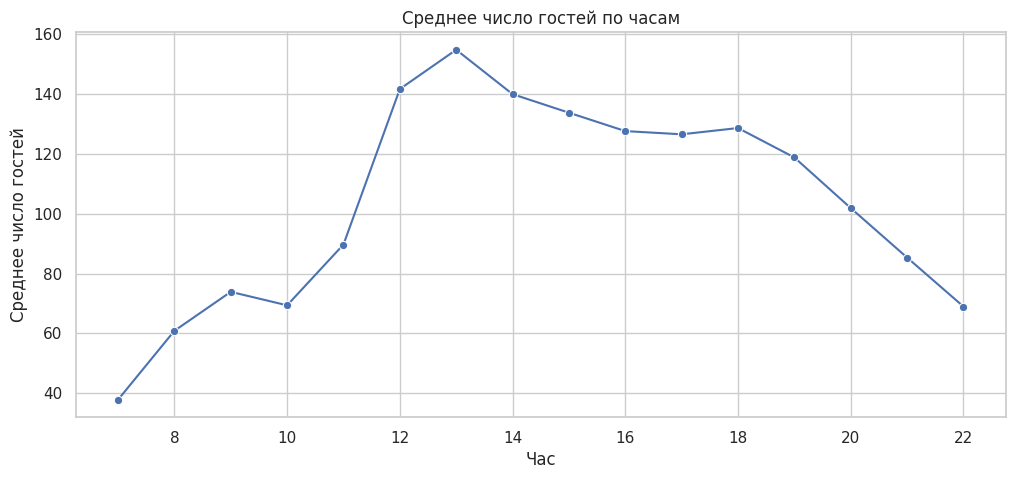

In [ ]:
hourly_mean = (
    train.groupby("sale_hour")["guests_count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_mean, x="sale_hour", y="guests_count", marker="o")
plt.title("Среднее число гостей по часам")
plt.xlabel("Час")
plt.ylabel("Среднее число гостей")
plt.show()

Среднее число гостей по дням недели

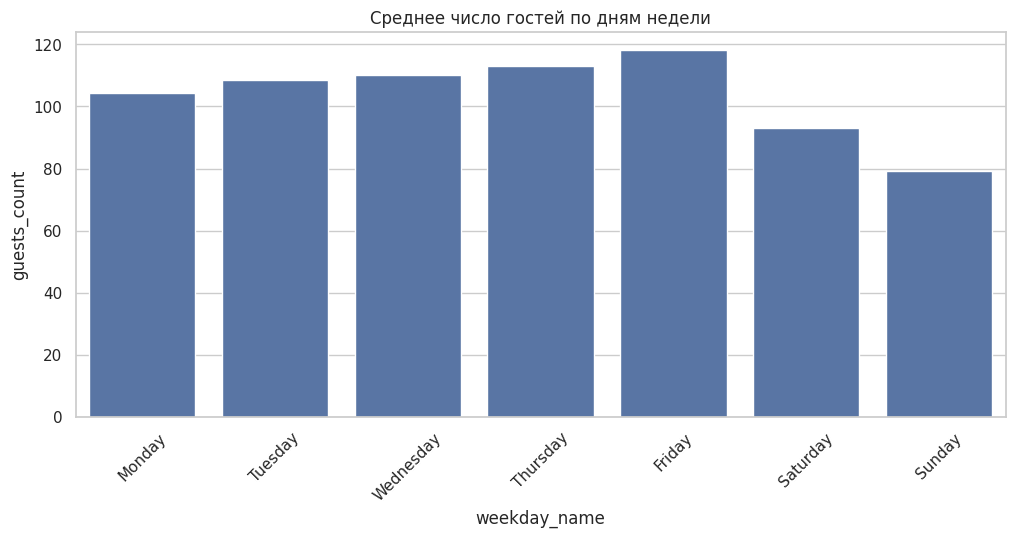

In [ ]:
weekday_mean = (
    train.groupby("weekday_name")["guests_count"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=weekday_mean, x="weekday_name", y="guests_count")
plt.title("Среднее число гостей по дням недели")
plt.xticks(rotation=45)
plt.show()

Heatmap: день недели x час

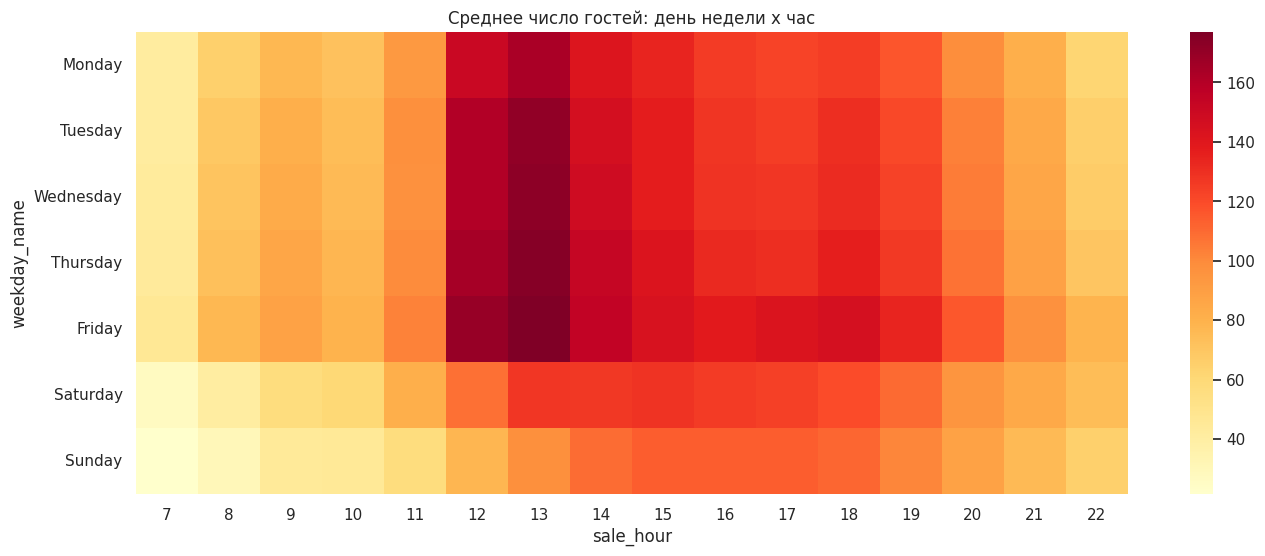

In [ ]:
pivot_hour_weekday = train.pivot_table(
    index="weekday_name",
    columns="sale_hour",
    values="guests_count",
    aggfunc="mean"
)

pivot_hour_weekday = pivot_hour_weekday.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_hour_weekday, cmap="YlOrRd")
plt.title("Среднее число гостей: день недели x час")
plt.show()

Анализ сезонности по месяцам

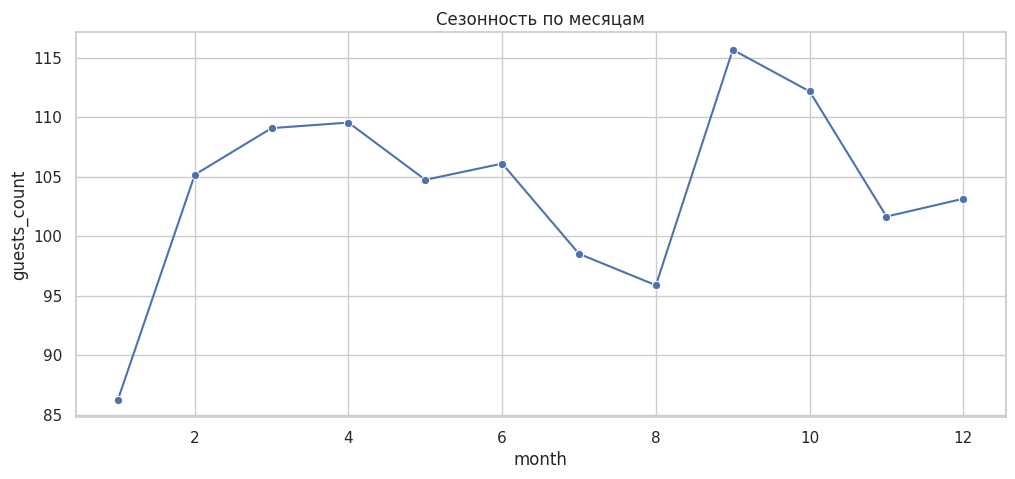

In [ ]:

monthly = (
    train.groupby("month")["guests_count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="month", y="guests_count", marker="o")
plt.title("Сезонность по месяцам")
plt.show()

Выбросы

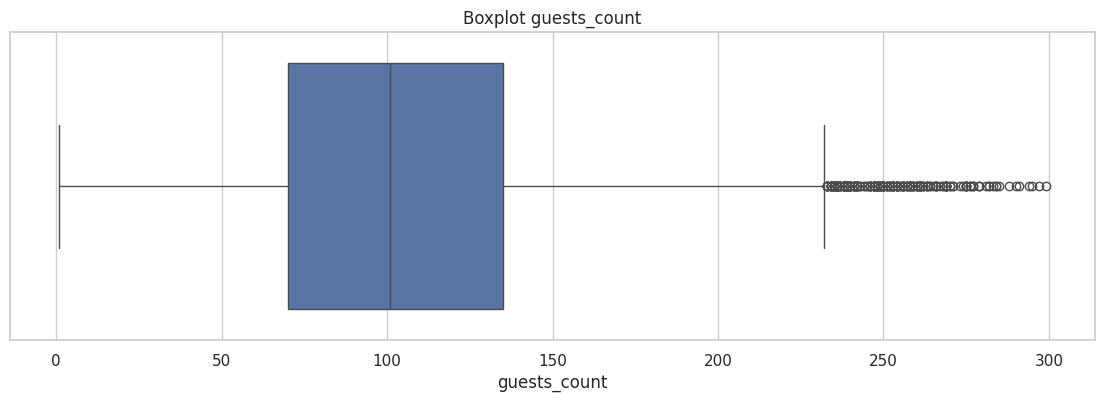

In [ ]:
plt.figure(figsize=(14, 4))
sns.boxplot(x=train["guests_count"])
plt.title("Boxplot guests_count")
plt.show()

Проверка полноты временного ряда

In [ ]:

print("Минимальная дата:", train["sale_date"].min())
print("Максимальная дата:", train["sale_date"].max())

expected_hours = (
    train["sale_date"].nunique() *
    train["sale_hour"].nunique()
)

actual_hours = len(train)

print("Ожидаемое число строк:", expected_hours)
print("Фактическое число строк:", actual_hours)

Минимальная дата: 2019-01-02 00:00:00
Максимальная дата: 2026-04-26 00:00:00
Ожидаемое число строк: 40688
Фактическое число строк: 40543


Анализ доступности сотрудников

Корреляции

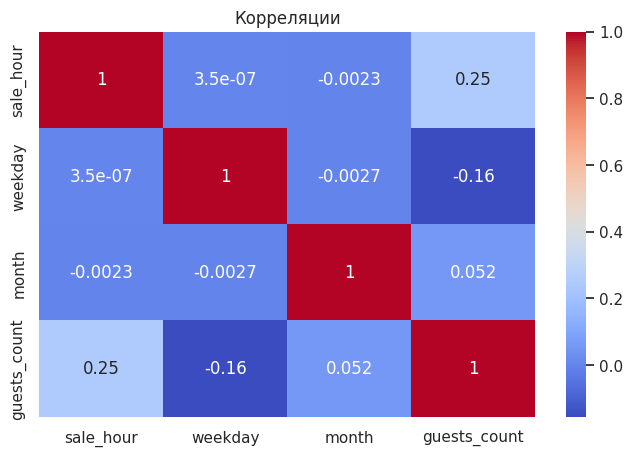

In [ ]:

corr_cols = [
    "sale_hour",
    "weekday",
    "month",
    "guests_count"
]

corr = train[corr_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляции")
plt.show()

RAW STATISTICS (guests_count)
count    40375.000000
mean       103.962328
std         45.170101
min          1.000000
25%         71.000000
50%        101.000000
75%        135.000000
max        299.000000
Name: guests_count, dtype: float64

Skew: 0.35117669034969506
Kurtosis: -0.08877216229158202


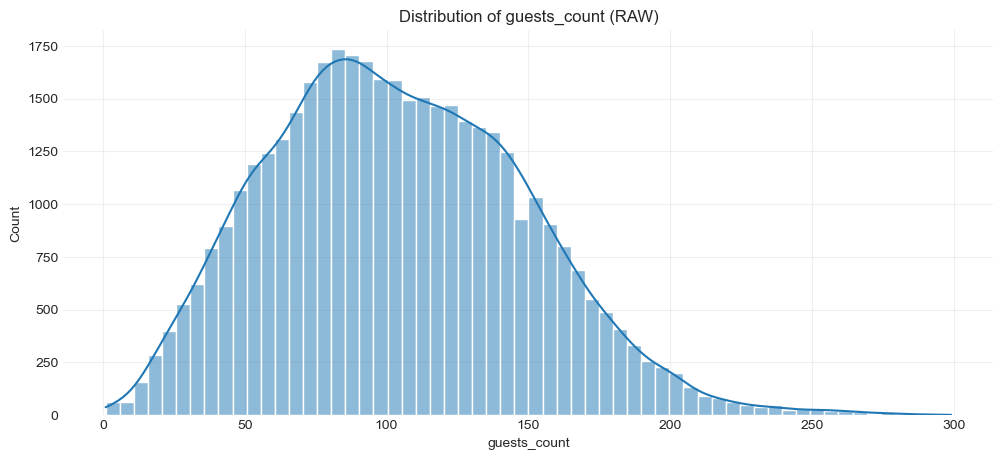

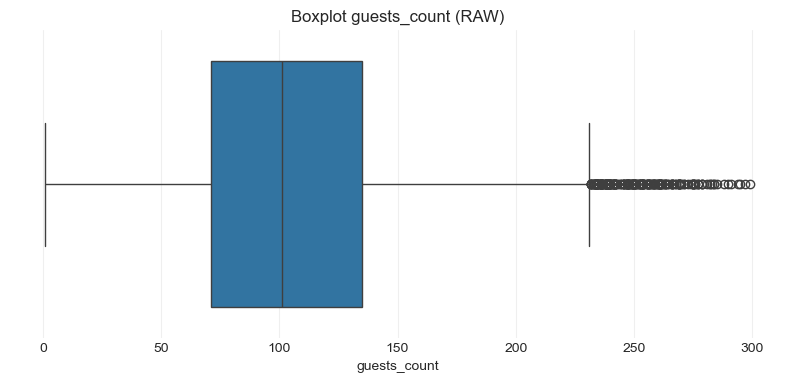


OUTLIERS (IQR)
Q1: 71.00
Q3: 135.00
IQR: 64.00
Lower bound: -25.00
Upper bound: 231.00
Outliers count: 237 (0.59%)

NORMALITY TEST
Shapiro p-value: 3.8228819881686803e-19
Not normal distribution

INTERPRETATION
Approximately symmetric

Median guests: 101
95% quantile: 180
99% quantile: 217


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

target = train["guests_count"]

# ============================================================
# БАЗОВАЯ СТАТИСТИКА
# ============================================================

print("=" * 40)
print("RAW STATISTICS (guests_count)")
print("=" * 40)

print(target.describe())

print("\nSkew:", target.skew())
print("Kurtosis:", target.kurtosis())

# ============================================================
# РАСПРЕДЕЛЕНИЕ
# ============================================================

plt.figure(figsize=(12,5))
sns.histplot(target, bins=60, kde=True)
plt.title("Distribution of guests_count (RAW)")
plt.xlabel("guests_count")
plt.show()

# ============================================================
# BOXPLOT (выбросы визуально)
# ============================================================

plt.figure(figsize=(10,4))
sns.boxplot(x=target)
plt.title("Boxplot guests_count (RAW)")
plt.show()

# ============================================================
# ВЫБРОСЫ (IQR)
# ============================================================

Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (target < lower) | (target > upper)

print("\n" + "=" * 40)
print("OUTLIERS (IQR)")
print("=" * 40)

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"Outliers count: {outliers.sum()} ({outliers.mean()*100:.2f}%)")

# ============================================================
# НОРМАЛЬНОСТЬ (Shapiro test)
# ============================================================

sample = target.sample(min(5000, len(target)), random_state=42)

stat, p = stats.shapiro(sample)

print("\n" + "=" * 40)
print("NORMALITY TEST")
print("=" * 40)

print("Shapiro p-value:", p)

if p > 0.05:
    print("≈ Normal distribution")
else:
    print("Not normal distribution")

# ============================================================
# ИНТЕРПРЕТАЦИЯ
# ============================================================

print("\n" + "=" * 40)
print("INTERPRETATION")
print("=" * 40)

skew = target.skew()

if skew > 0.5:
    print("Right-skewed (long tail to the right)")
elif skew < -0.5:
    print("Left-skewed")
else:
    print("Approximately symmetric")

print(f"\nMedian guests: {target.median():.0f}")
print(f"95% quantile: {target.quantile(0.95):.0f}")
print(f"99% quantile: {target.quantile(0.99):.0f}")

## TIME SERIES ANALYSIS (TSA)

In [ ]:


# ============================================================
# 1.2 ПРОВЕРКА ПРОПУСКОВ
# ============================================================

# Создаем полный диапазон часов
full_range = pd.date_range(
    start=train.index.min(),
    end=train.index.max(),
    freq="h"
)

missing_hours = len(full_range.difference(train.index))

print(f"\nПропущенных часов: {missing_hours}")

# ============================================================
# 1.3 ПРОВЕРКА ВЫБРОСОВ
# ============================================================

Q1 = train["guests_count"].quantile(0.25)
Q3 = train["guests_count"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train[
    (train["guests_count"] < lower) |
    (train["guests_count"] > upper)
]

print(f"Выбросов найдено: {len(outliers)}")


Пропущенных часов: 1
Выбросов найдено: 231


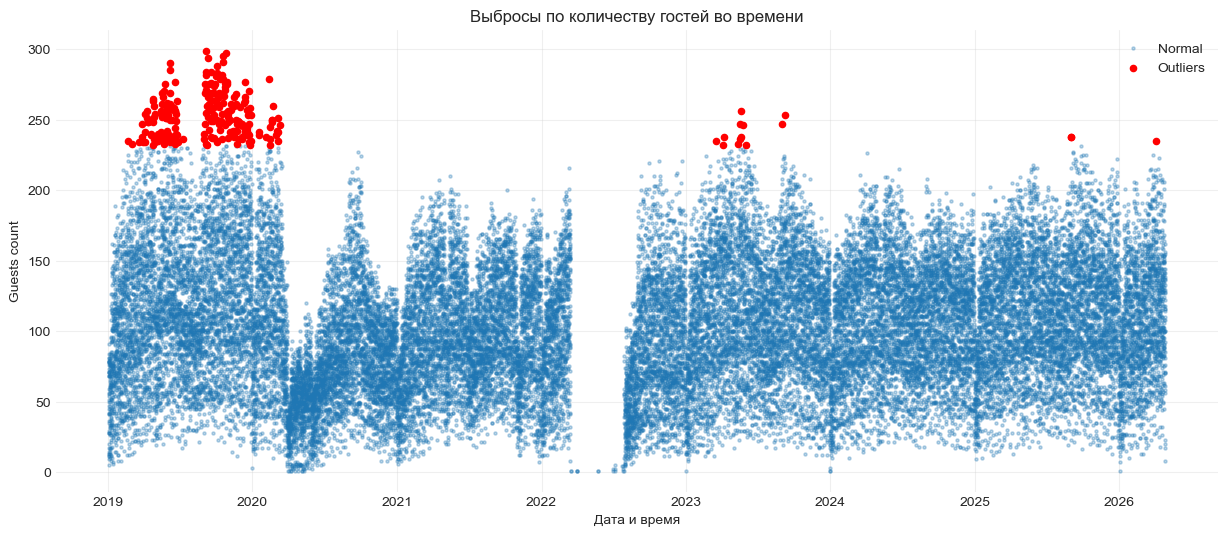

In [ ]:
import matplotlib.pyplot as plt

# убеждаемся, что datetime в правильном формате
train["datetime"] = pd.to_datetime(train["datetime"])

# помечаем выбросы
train["is_outlier"] = (
    (train["guests_count"] < lower) |
    (train["guests_count"] > upper)
)

plt.figure(figsize=(15,6))

# обычные точки
plt.scatter(
    train.loc[~train["is_outlier"], "datetime"],
    train.loc[~train["is_outlier"], "guests_count"],
    s=5,
    alpha=0.3,
    label="Normal"
)

# выбросы
plt.scatter(
    train.loc[train["is_outlier"], "datetime"],
    train.loc[train["is_outlier"], "guests_count"],
    color="red",
    s=20,
    label="Outliers"
)

plt.title("Выбросы по количеству гостей во времени")
plt.xlabel("Дата и время")
plt.ylabel("Guests count")
plt.legend()
plt.show()

### 1.4 STL DECOMPOSITION и выбросы

In [ ]:
# STL устойчив к выбросам
# period=24 -> суточная сезонность

stl = STL(
    train["guests_count"],
    period=24,
    robust=True
)
result = stl.fit()
train["trend"] = result.trend
train["seasonal"] = result.seasonal
train["residual"] = result.resid

АНОМАЛЬНЫЕ ПЕРИОДЫ

Аномалий STL: 63


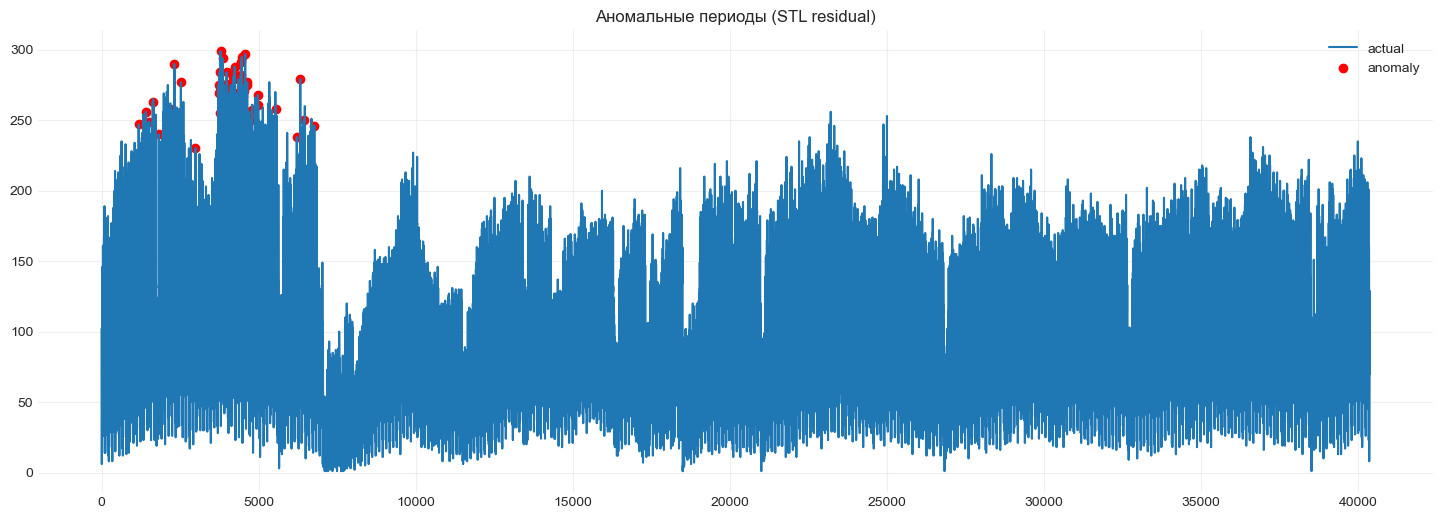

In [ ]:
resid = train["residual"]

std = resid.std()
mean = resid.mean()

anomaly_threshold = 3 * std

train["anomaly_stl"] = np.abs(resid - mean) > anomaly_threshold

print("Аномалий STL:", train["anomaly_stl"].sum())

plt.figure(figsize=(18,6))
plt.plot(train.index, train["guests_count"], label="actual")
plt.scatter(
    train.index[train["anomaly_stl"]],
    train["guests_count"][train["anomaly_stl"]],
    color="red",
    label="anomaly"
)
plt.legend()
plt.title("Аномальные периоды (STL residual)")
plt.show()

In [ ]:
rolling_mean = train["guests_count"].rolling(24).mean()
rolling_std = train["guests_count"].rolling(24).std()

z = (train["guests_count"] - rolling_mean) / rolling_std

train["anomaly_z"] = np.abs(z) > 3

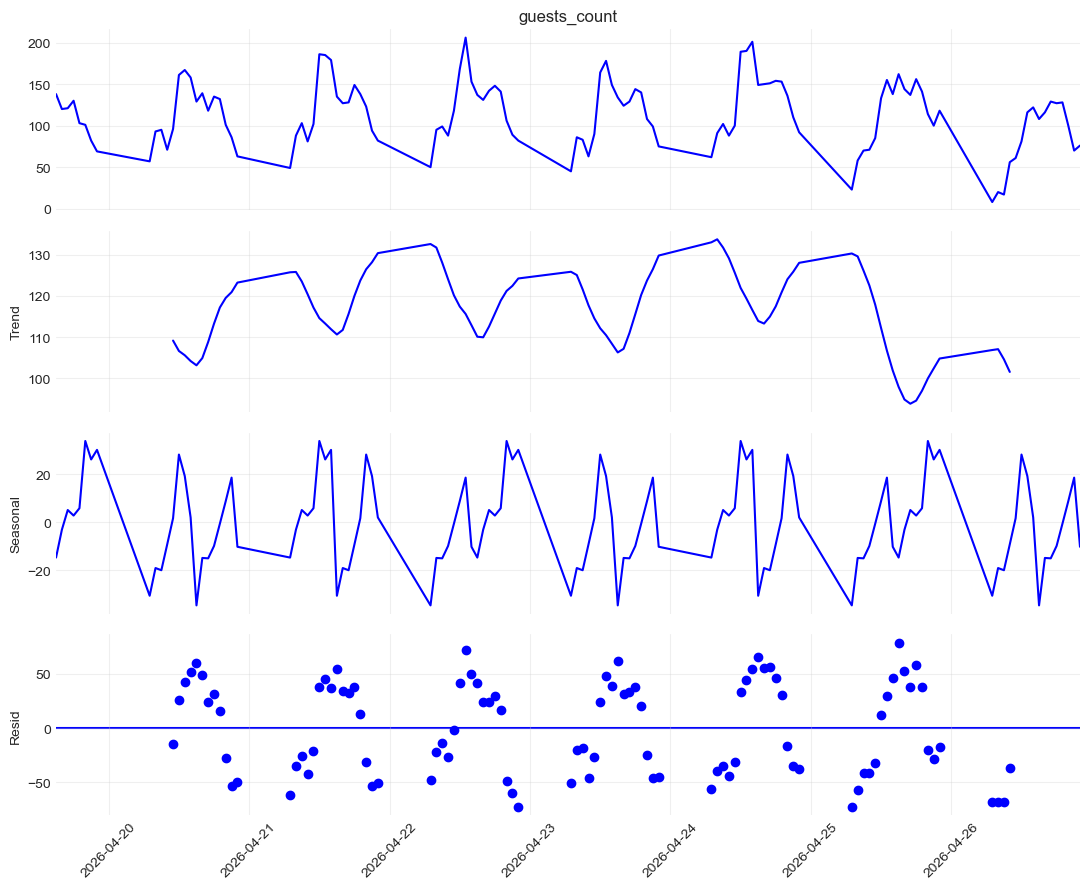

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams

N = 24 * 5  # 5 дней
df_small = train.tail(N).copy()
df_small = df_small.set_index("datetime")
rcParams['figure.figsize'] = 11, 9

decompose = seasonal_decompose(
    df_small["guests_count"],
    model="additive",
    period=24
)

fig = decompose.plot()



#цвет
for ax in fig.axes:

    ax.grid(True)

    ax.tick_params(axis='x', rotation=45)

    for line in ax.get_lines():
        line.set_color("blue")


plt.tight_layout()
plt.show()

In [ ]:
print("mean residual:", result.resid.mean())
print("std residual:", result.resid.std())
print("min residual:", result.resid.min())
print("max residual:", result.resid.max())

mean residual: 0.37414685532959874
std residual: 37.1086733831794
min residual: -113.04649638831927
max residual: 192.9755943276349


### 1.6 проверка на стационарность

Стационарность - статистические характеристики (среднее, дисперсия) не изменяются со временем.
Стационарные ряды не имеют явного тренда или сезонности. Для анализа многих методов (например, ARIMA) временной ряд нужно сделать стационарным.


1) ADF Test (Augmented Dickey-Fuller test) — это статистический тест, который отвечает на вопрос:

«Зависит ли значение временного ряда от времени или нет?»
Или чуть точнее: «Является ли ряд стационарным?»

p-value < 0.05  - стационарный ряд

2) KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin test) — это тест, который отвечает на тот же вопрос, что и ADF, но с точностью до наоборот.

«Есть ли у ряда свойство стационарности?»

p-value > 0.05	- стационарный ряд

In [ ]:
# ============================================================
# 1.6 ADF TEST
# ============================================================

print("\n" + "=" * 40)
print("ADF TEST")
print("=" * 40)

adf_result = adfuller(train["guests_count"])

print(f"Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# ============================================================
# 1.7 KPSS TEST
# ============================================================

print("\n" + "=" * 40)
print("KPSS TEST")
print("=" * 40)

kpss_result = kpss(
    train["guests_count"],
    regression="c",
    nlags="auto"
)

print(f"Statistic: {kpss_result[0]}")
print(f"p-value: {kpss_result[1]}")


ADF TEST
Statistic: -13.027459882425289
p-value: 2.383119922559087e-24

KPSS TEST
Statistic: 4.965720936083615
p-value: 0.01


ВЫВОД: Результаты противоречивы (требуется дополнительный анализ)

### Дифференцирование

Сезонное дифференцирование помогает устранить сезонные колебания
![image.png](attachment:d51914fa-891e-435a-b144-443a513ec19a.png)
где s — это период сезонности ( 24 часа будет)


In [ ]:
# Суточное дифференцирование
train["diff_24"] = (
    train["guests_count"] -
    train["guests_count"].shift(24)
)

diff_series = train["diff_24"].dropna()

In [ ]:
# 1.6 ADF TEST
print("\n" + "=" * 40)
print("ADF TEST")
print("=" * 40)

adf_result = adfuller(diff_series)

print(f"Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# 1.7 KPSS TEST
print("\n" + "=" * 40)
print("KPSS TEST")
print("=" * 40)

kpss_result = kpss(diff_series ,
    regression="c",
    nlags="auto"
)

print(f"Statistic: {kpss_result[0]}")
print(f"p-value: {kpss_result[1]}")


ADF TEST
Statistic: -42.747093589593
p-value: 0.0

KPSS TEST
Statistic: 0.02424950558501686
p-value: 0.1


### ACF и PACF
Это графики, которые помогают понять, как прошлые значения ряда влияют на будущие.

1) ACF (Autocorrelation Function) — автокорреляционная функция
Что показывает: Связь между рядом и его сдвинутой копией (лагом).
«Насколько значение сегодня похоже на значение вчера, позавчера, 3 дня назад и т.д.»

2) PACF (Partial Autocorrelation Function) — частная автокорреляция
Что показывает: Связь с лагом после устранения влияния промежуточных лагов.
«Чистое влияние значения из позавчера на сегодня, без учёта того, что вчера уже всё объяснило».

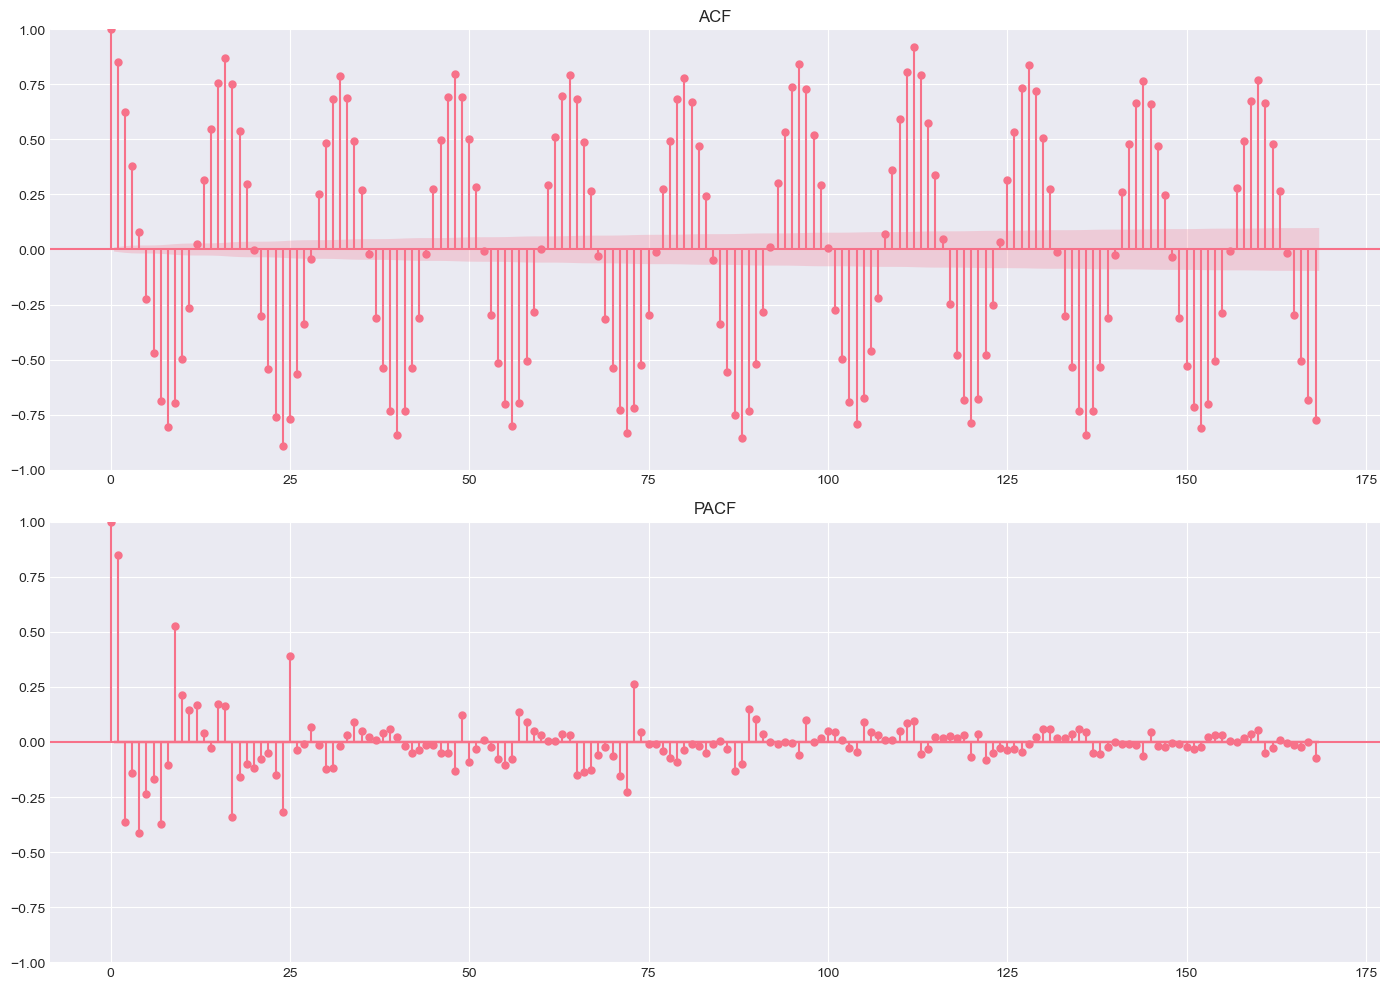

In [ ]:
# ============================================================
# 1.10 ACF / PACF
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)

plot_acf(
    diff_series,
    lags=168,
    ax=axes[0]
)

plot_pacf(
    diff_series,
    lags=168,
    ax=axes[1]
)

axes[0].set_title("ACF")
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()

### 1.11  ЛАГИ

| Лаг | Что это значит            | Почему важно                                                                             |
| --- | ------------------------- | ---------------------------------------------------------------------------------------- |
| 1   | 1 час назад               | Показывает самое свежее состояние системы: как изменился поток гостей буквально сейчас   |
| 2   | 2 часа назад              | Помогает уловить короткие циклы внутри дня (например, спад/рост после еды)               |
| 24  | Вчера в то же время       | Основная суточная сезонность: одинаковые часы разных дней ведут себя похоже              |
| 48  | Позавчера в то же время   | Усиливает стабильность суточного паттерна, помогает модели не “забывать” предыдущий день |
| 72  | 3 дня назад в то же время | Улавливает среднесрочные повторяющиеся поведенческие паттерны                            |
| 168 | Ровно неделю назад        | Недельная сезонность: сравнение одинаковых дней недели (например, пятница с пятницей)    |


### 1.12 ПРОВЕРКА LEAKAGE

1. Обнаружена сильная суточная сезонность.
2. STL decomposition выделила:
   - тренд,
   - сезонность,
   - остатки.
3. diff(24) улучшил стационарность ряда.
4. ACF/PACF подтвердили важность лагов:
   24, 48, 72, 168.
5. Leakage критичного уровня не обнаружен.

In [ ]:
# Проверяем корреляцию STL trend
corr = train["trend"].corr(
    train["guests_count"]
)

print(f"Trend correlation: {corr:.3f}")

if corr > 0.95:
    print("Возможна утечка данных")
else:
    print("Критичной утечки не обнаружено")

Trend correlation: 0.508
Критичной утечки не обнаружено


### разделение train test

STEP 1: CLEAN DATA + STL
Начало clean data: 2022-09-01 07:00:00
Размер данных: 21319
✅ STL decomposition выполнена


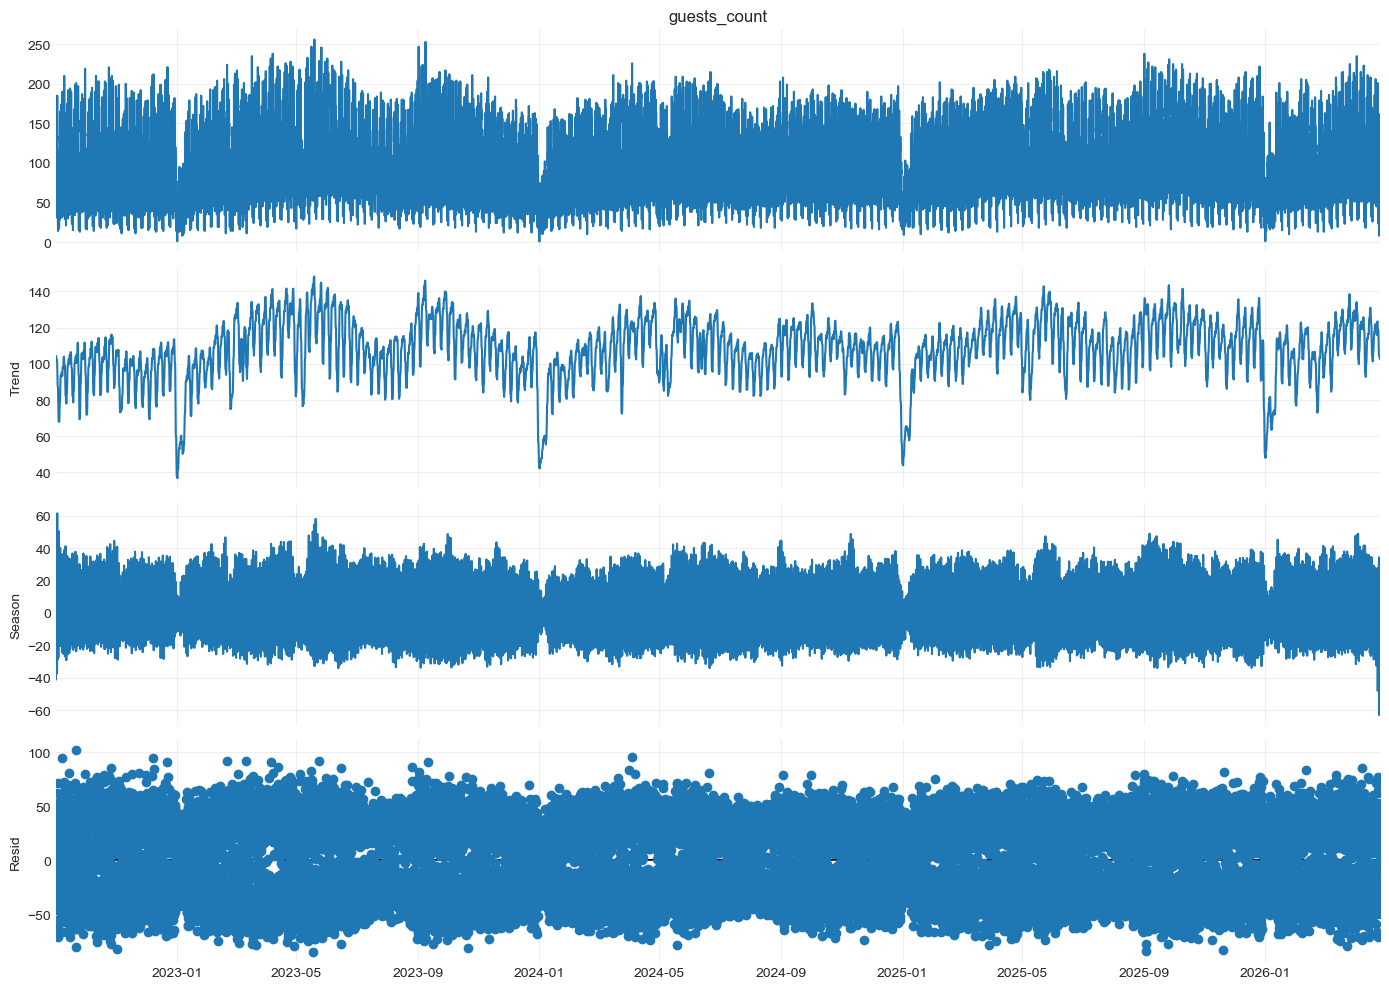

In [ ]:
# ============================================================
# STEP 1: CLEAN DATA + STL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL

print("=" * 60)
print("STEP 1: CLEAN DATA + STL")
print("=" * 60)

# ============================================================
# 1.1 DATETIME
# ============================================================

train["datetime"] = (
    pd.to_datetime(train["sale_date"]) +
    pd.to_timedelta(train["sale_hour"], unit="h")
)

train = (
    train
    .sort_values("datetime")
    .set_index("datetime")
)

# ============================================================
# 1.2 REMOVE BAD PERIOD
# ============================================================

# удаляем нестабильный период
cut_date = "2022-09-01"

train = train.loc[cut_date:].copy()

print(f"Начало clean data: {train.index.min()}")
print(f"Размер данных: {len(train)}")

# ============================================================
# 1.3 STL DECOMPOSITION
# ============================================================

stl = STL(
    train["guests_count"],
    period=24,
    robust=True
)

result = stl.fit()

# ============================================================
# 1.4 SAVE STL COMPONENTS
# ============================================================

train["trend"] = result.trend
train["seasonal"] = result.seasonal
train["residual"] = result.resid

print("✅ STL decomposition выполнена")

# ============================================================
# 1.5 VISUALIZATION
# ============================================================

fig = result.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()

plt.show()

##  ETS MODEL

ETS = Error Trend Seasonality


После cut_date: 21151 строк
Train size: 31592
Valid size: 168
✅ ETS обучена

ETS METRICS
MAE : 15.411
RMSE: 18.504
R2  : 0.773


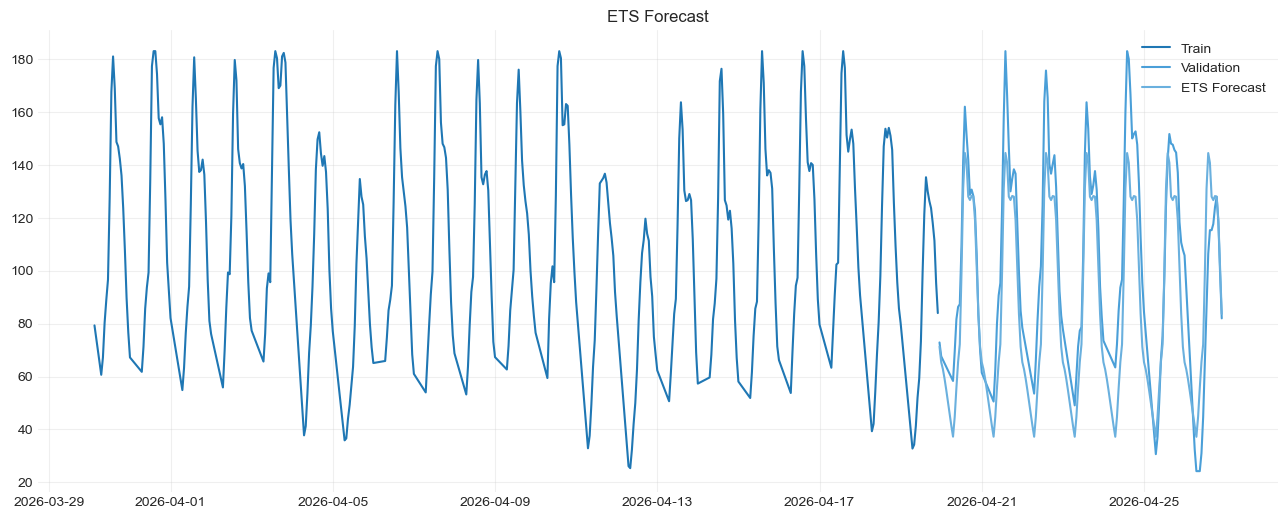

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



# ============================================================
# 3.1 CUT UNSTABLE PERIOD
# ============================================================

cut_date = "2022-09-01"

train_filtered = train.loc[
    train.index >= cut_date
].copy()

print(f"После cut_date: {len(train_filtered)} строк")

# ============================================================
# 3.2 FULL HOURLY INDEX
# ============================================================

full_index = pd.date_range(

    start=train_filtered.index.min(),

    end=train_filtered.index.max(),

    freq="h"
)

train_filtered = (
    train_filtered
    .reindex(full_index)
)

# ============================================================
# 3.3 INTERPOLATION
# ============================================================

train_filtered["guests_count"] = (
    train_filtered["guests_count"]
    .interpolate(method="time")
)


# ============================================================
# 3.4 REMOVE OUTLIERS
# ============================================================

q01 = train_filtered["guests_count"].quantile(0.01)
q99 = train_filtered["guests_count"].quantile(0.99)

train_filtered["guests_count"] = (
    train_filtered["guests_count"]
    .clip(q01, q99)
)

# ============================================================
# 3.5 TRAIN / VALID
# ============================================================

forecast_horizon = 24 * 7

train_ets = train_filtered.iloc[:-forecast_horizon]

valid_ets = train_filtered.iloc[-forecast_horizon:]

print(f"Train size: {len(train_ets)}")
print(f"Valid size: {len(valid_ets)}")

# ============================================================
# 3.6 ETS MODEL
# ============================================================

ets_model = ExponentialSmoothing(

    train_ets["guests_count"],

    trend="add",

    seasonal="add",

    seasonal_periods=24,

    damped_trend=True
)

# ============================================================
# 3.7 FIT
# ============================================================

ets_fit = ets_model.fit(

    optimized=True,

    use_brute=True
)

print("✅ ETS обучена")

# ============================================================
# 3.8 FORECAST
# ============================================================

ets_forecast = ets_fit.forecast(
    forecast_horizon
)

# ============================================================
# 3.9 METRICS
# ============================================================

mae = mean_absolute_error(

    valid_ets["guests_count"],

    ets_forecast
)

rmse = np.sqrt(

    mean_squared_error(

        valid_ets["guests_count"],

        ets_forecast
    )
)

r2 = r2_score(

    valid_ets["guests_count"],

    ets_forecast
)

print("\nETS METRICS")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

# ============================================================
# 3.10 VISUALIZATION
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(

    train_ets.index[-500:],

    train_ets["guests_count"].iloc[-500:],

    label="Train"
)

plt.plot(

    valid_ets.index,

    valid_ets["guests_count"],

    label="Validation"
)

plt.plot(

    valid_ets.index,

    ets_forecast,

    label="ETS Forecast"
)

plt.title("ETS Forecast")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

После cut_date: 21151 строк
Train size: 31592
Valid size: 168
✅ ETS обучена

ETS METRICS
MAE : 0.264
RMSE: 0.316
R2  : 0.617


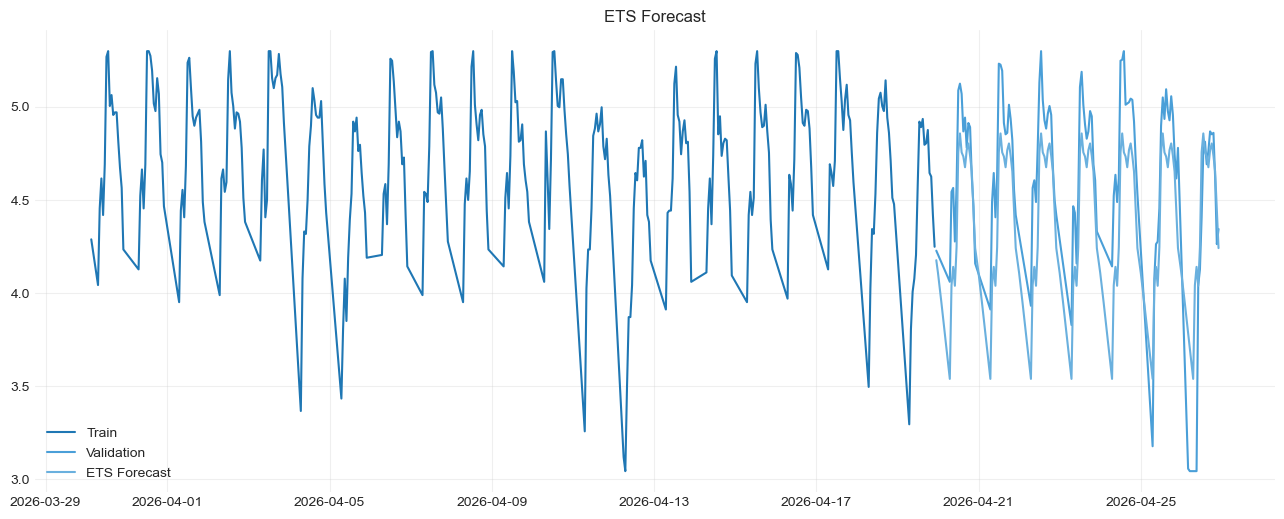

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



# ============================================================
# 3.1 CUT UNSTABLE PERIOD
# ============================================================

cut_date = "2022-09-01"

train_filtered = train.loc[
    train.index >= cut_date
].copy()

# ============================================================
# 3.1.1 LOG TRANSFORM (TEST)
# ============================================================

train_filtered["guests_count"] = np.log1p(train_filtered["guests_count"])

print(f"После cut_date: {len(train_filtered)} строк")

# ============================================================
# 3.2 FULL HOURLY INDEX
# ============================================================

full_index = pd.date_range(

    start=train_filtered.index.min(),

    end=train_filtered.index.max(),

    freq="h"
)

train_filtered = (
    train_filtered
    .reindex(full_index)
)

# ============================================================
# 3.3 INTERPOLATION
# ============================================================

train_filtered["guests_count"] = (
    train_filtered["guests_count"]
    .interpolate(method="time")
)

# ============================================================
# 3.4 REMOVE OUTLIERS
# ============================================================

q01 = train_filtered["guests_count"].quantile(0.01)
q99 = train_filtered["guests_count"].quantile(0.99)

train_filtered["guests_count"] = (
    train_filtered["guests_count"]
    .clip(q01, q99)
)

# ============================================================
# 3.5 TRAIN / VALID
# ============================================================

forecast_horizon = 24 * 7

train_ets = train_filtered.iloc[:-forecast_horizon]

valid_ets = train_filtered.iloc[-forecast_horizon:]

print(f"Train size: {len(train_ets)}")
print(f"Valid size: {len(valid_ets)}")

# ============================================================
# 3.6 ETS MODEL
# ============================================================

ets_model = ExponentialSmoothing(

    train_ets["guests_count"],

    trend="add",

    seasonal="add",

    seasonal_periods=24,

    damped_trend=True
)

# ============================================================
# 3.7 FIT
# ============================================================

ets_fit = ets_model.fit(

    optimized=True,

    use_brute=True
)

print("✅ ETS обучена")

# ============================================================
# 3.8 FORECAST
# ============================================================

ets_forecast = ets_fit.forecast(
    forecast_horizon
)

# ============================================================
# 3.9 METRICS
# ============================================================

mae = mean_absolute_error(

    valid_ets["guests_count"],

    ets_forecast
)

rmse = np.sqrt(

    mean_squared_error(

        valid_ets["guests_count"],

        ets_forecast
    )
)

r2 = r2_score(

    valid_ets["guests_count"],

    ets_forecast
)

print("\nETS METRICS")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

# ============================================================
# 3.10 VISUALIZATION
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(

    train_ets.index[-500:],

    train_ets["guests_count"].iloc[-500:],

    label="Train"
)

plt.plot(

    valid_ets.index,

    valid_ets["guests_count"],

    label="Validation"
)

plt.plot(

    valid_ets.index,

    ets_forecast,

    label="ETS Forecast"
)

plt.title("ETS Forecast")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## PROPHET MODEL

STEP 5: PROPHET


21:11:05 - cmdstanpy - INFO - Chain [1] start processing
21:11:11 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet обучен

PROPHET METRICS
MAE : 10.917
RMSE: 14.556
R2  : 0.860


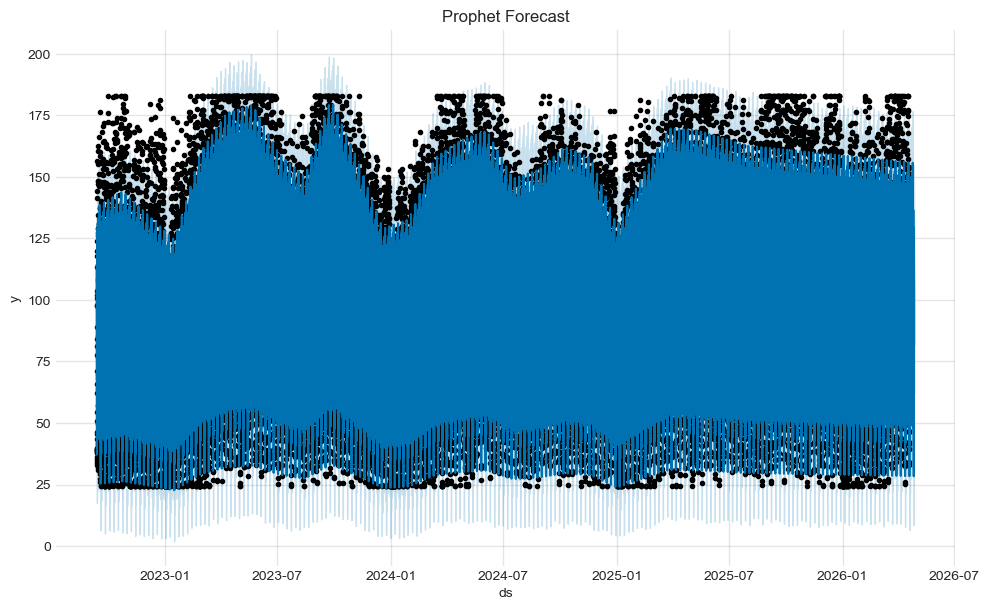

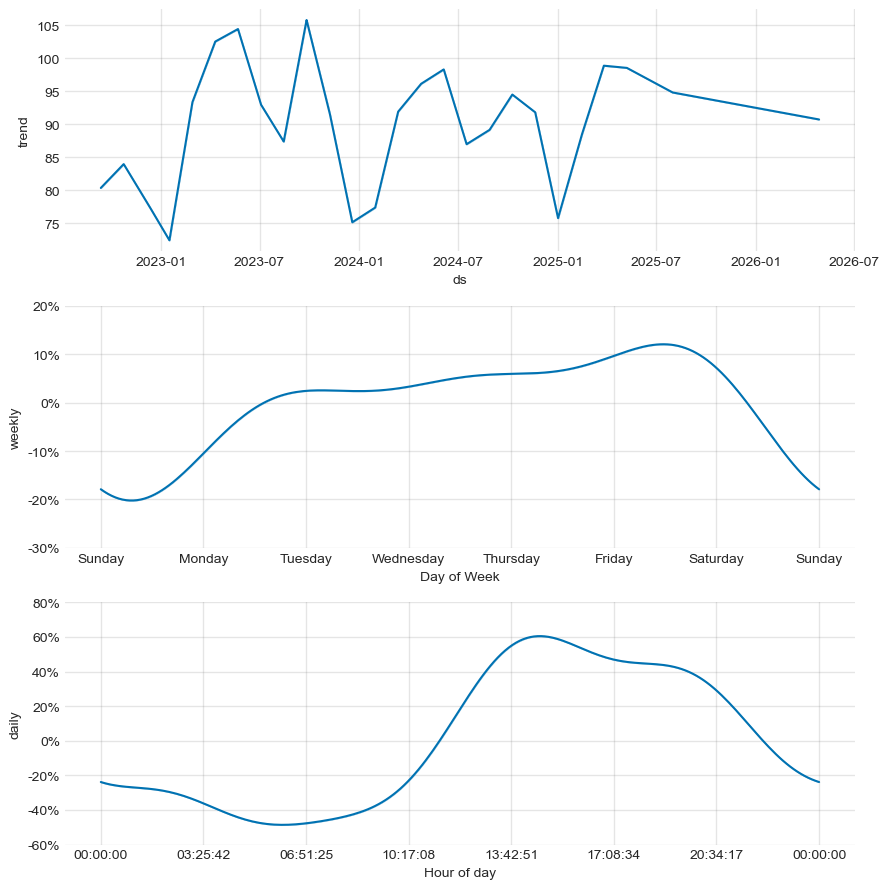

In [ ]:
from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 5: PROPHET")
print("=" * 60)

# ============================================================
# 5.1 CUT UNSTABLE PERIOD
# ============================================================

cut_date = "2022-09-01"

prophet_data = train.loc[
    train.index >= cut_date
].copy()

# ============================================================
# 5.2 FULL HOURLY INDEX
# ============================================================

full_index = pd.date_range(

    start=prophet_data.index.min(),

    end=prophet_data.index.max(),

    freq="h"
)

prophet_data = (
    prophet_data
    .reindex(full_index)
)

# ============================================================
# 5.3 INTERPOLATION
# ============================================================

prophet_data["guests_count"] = (
    prophet_data["guests_count"]
    .interpolate(method="time")
)

# ============================================================
# 5.3.1 SMOOTHING (TEST IMPROVEMENT)
# ============================================================

prophet_data["guests_count"] = (
    prophet_data["guests_count"]
    .rolling(window=3, min_periods=1)
    .mean()
)
# ============================================================
# 5.4 REMOVE OUTLIERS
# ============================================================

q01 = prophet_data["guests_count"].quantile(0.01)
q99 = prophet_data["guests_count"].quantile(0.99)

prophet_data["guests_count"] = (
    prophet_data["guests_count"]
    .clip(q01, q99)
)

# ============================================================
# 5.5 PREPARE FOR PROPHET
# ============================================================

prophet_data.index.name = "datetime"

prophet_df = (
    prophet_data
    .reset_index()[[
        "datetime",
        "guests_count"
    ]]
    .copy()
)

prophet_df.columns = [
    "ds",
    "y"
]

# ============================================================
# 5.6 TRAIN / VALID
# ============================================================

forecast_horizon = 24 * 7

train_df = prophet_df.iloc[:-forecast_horizon]

valid_df = prophet_df.iloc[-forecast_horizon:]

# ============================================================
# 5.7 MODEL
# ============================================================

model = Prophet(

    yearly_seasonality=False,

    weekly_seasonality=True,

    daily_seasonality=True,

    changepoint_prior_scale=0.2,

    seasonality_mode="multiplicative"
)

# ============================================================
# 5.8 FIT
# ============================================================

model.fit(train_df)

print("✅ Prophet обучен")

# ============================================================
# 5.9 FUTURE
# ============================================================

future = model.make_future_dataframe(

    periods=forecast_horizon,

    freq="h"
)

forecast = model.predict(future)

# ============================================================
# 5.10 VALIDATION FORECAST
# ============================================================

pred = (
    forecast["yhat"]
    .iloc[-forecast_horizon:]
    .values
)

# ============================================================
# 5.11 METRICS
# ============================================================

mae = mean_absolute_error(

    valid_df["y"],

    pred
)

rmse = np.sqrt(

    mean_squared_error(

        valid_df["y"],

        pred
    )
)

r2 = r2_score(

    valid_df["y"],

    pred
)

print("\nPROPHET METRICS")

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

# ============================================================
# 5.12 VISUALIZATION
# ============================================================

fig = model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

fig2 = model.plot_components(forecast)

plt.show()


Pipeline проекта:

1. STL decomposition
2. Stationarity analysis
3. Feature Engineering
4. ETS baseline model
5. XGBoost residual boosting
6. Hybrid forecasting
7. Feature importance analysis
8. SHAP interpretation

STEP 5 — INTERPRETABILITY & FINAL VISUALIZATION
✅ DataFrame с прогнозами создан

Построение главного графика...


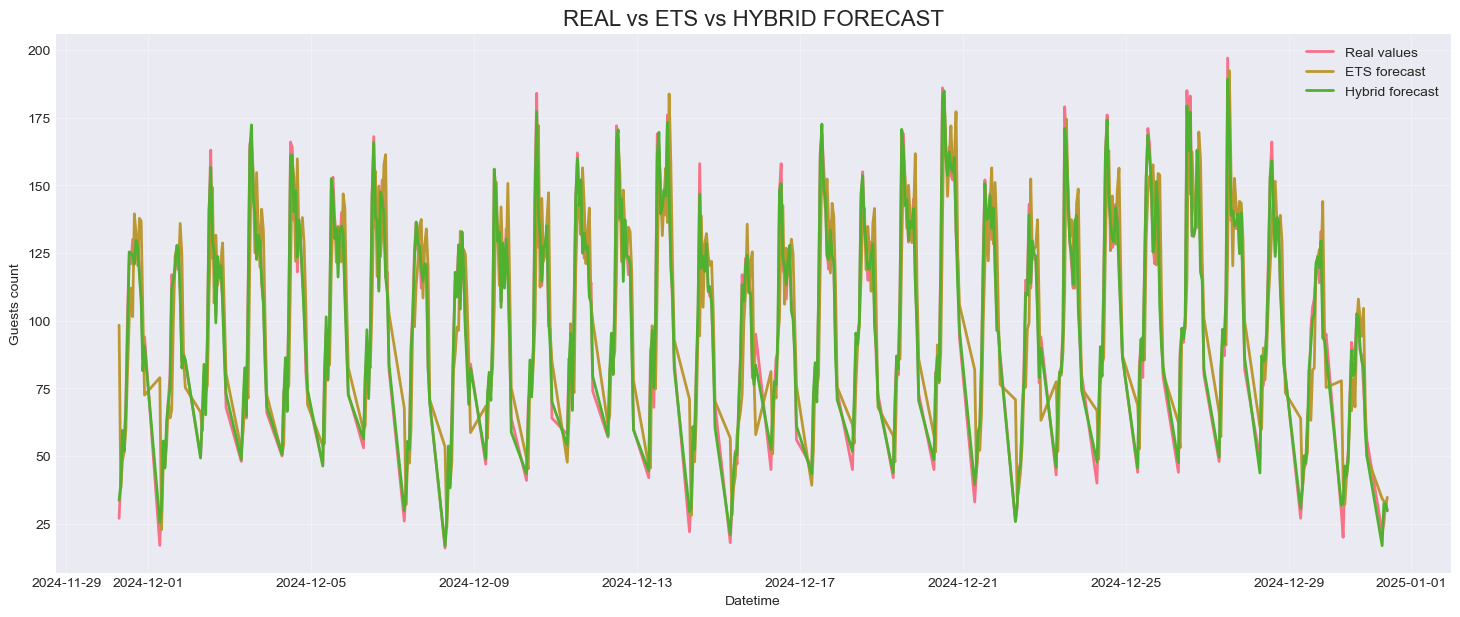


Анализ ошибок модели...
Средняя ошибка Hybrid: 0.2273
Std ошибки Hybrid: 5.7032


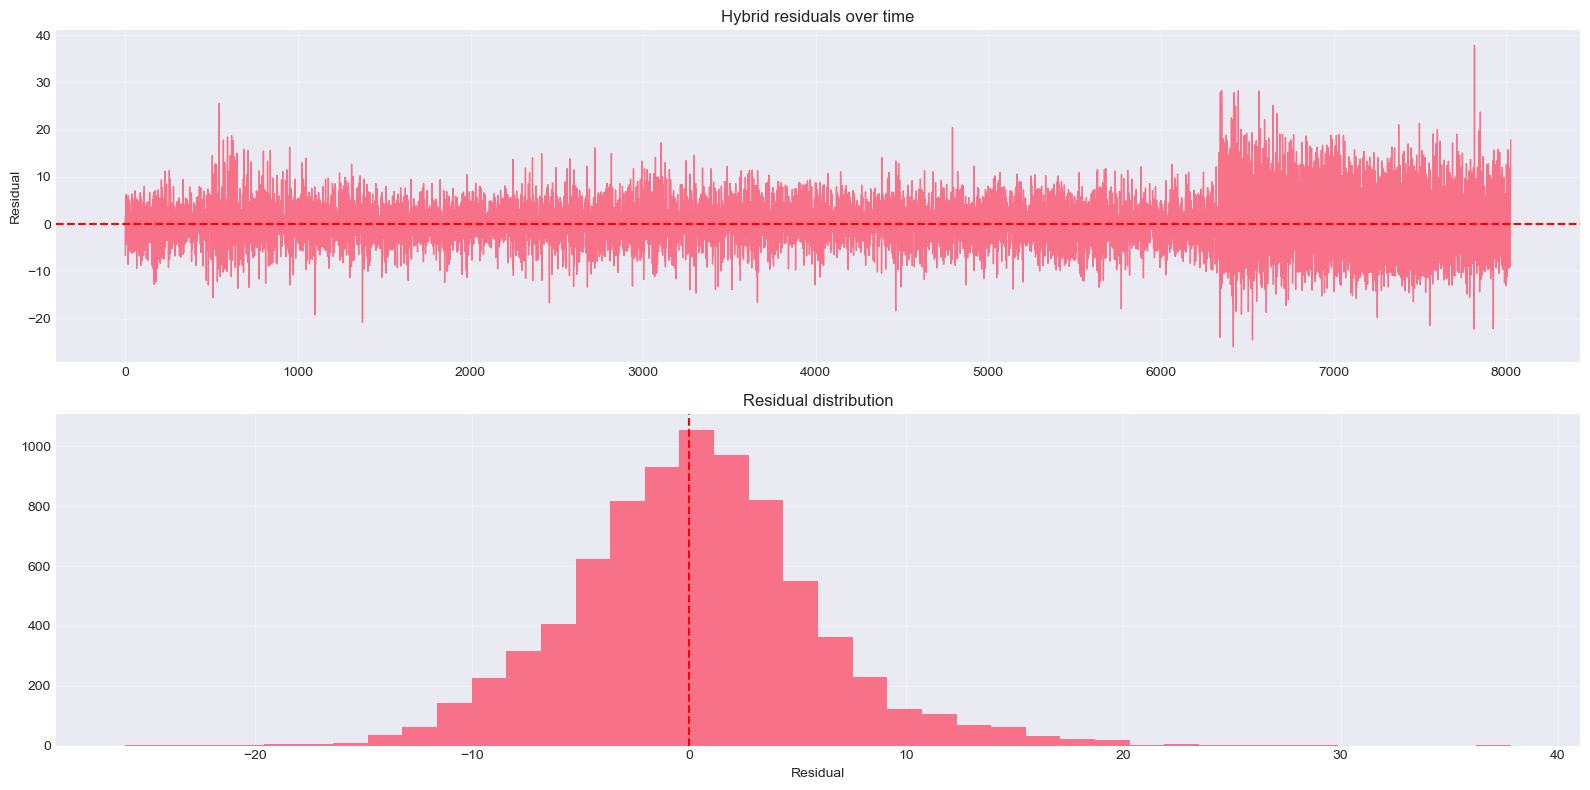


Feature importance visualization...


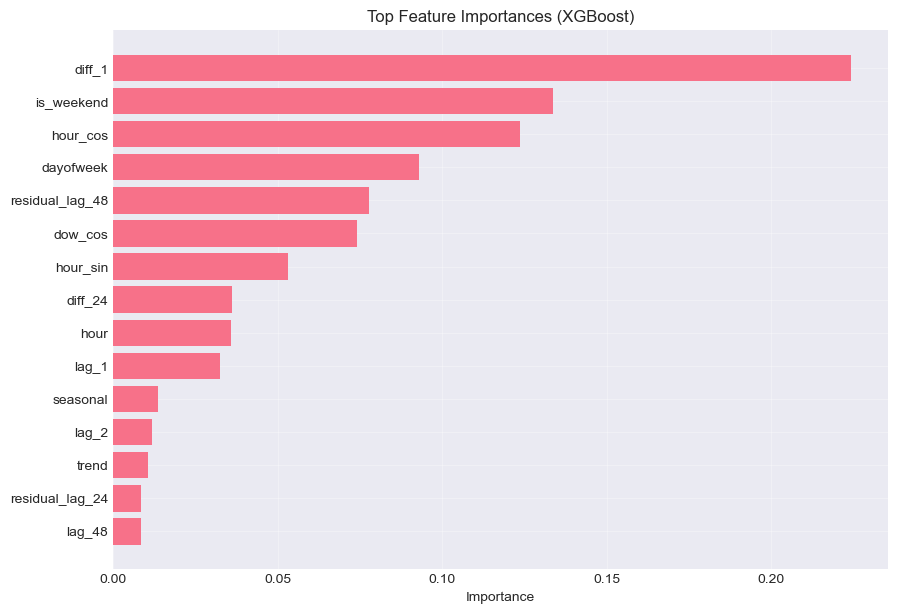


SHAP analysis...
✅ SHAP values рассчитаны


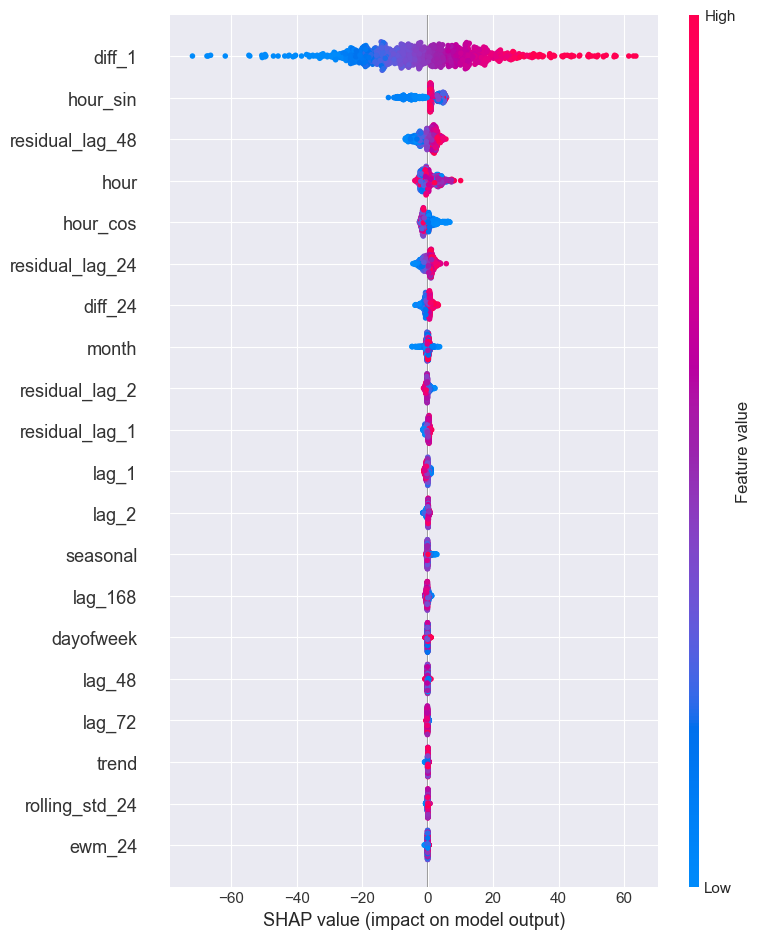


FINAL METRICS
ETS MAE    : 18.313
Hybrid MAE : 4.324

Hybrid RMSE: 5.707
Hybrid R2  : 0.981

✅ Hybrid model improves ETS forecast

FINAL INTERPRETATION


1. STL decomposition позволила выделить:
   - trend,
   - seasonality,
   - residual components.

2. ETS модель хорошо моделирует:
   - базовую структуру ряда,
   - тренд,
   - сезонность.

3. XGBoost прогнозирует residual errors ETS:
   - локальные колебания,
   - nonlinear effects,
   - сложные зависимости.

4. Использована hybrid architecture:
   ETS + Gradient Boosting.

5. Direct Strategy уменьшает accumulation error,
   так как прогнозируется correction напрямую.

6. Data leakage предотвращен:
   - все lag признаки используют shift(),
   - future values не используются,
   - residual feature текущего времени исключен.

7. Feature importance показывает:
   модель опирается на:
   - seasonality,
   - lag dependencies,
   - hourly patterns,
   - weekend effects.

8. Hybrid model показывает высокое качество
   forecasting благодаря

In [ ]:
# ============================================================
# STEP 5 — INTERPRETABILITY & FINAL VISUALIZATION
# Explainability + Diagnostics + Forecast Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 60)
print("STEP 5 — INTERPRETABILITY & FINAL VISUALIZATION")
print("=" * 60)

# ============================================================
# 5.1 СОЗДАЕМ DATAFRAME С ПРОГНОЗАМИ
# ============================================================

results_df = pd.DataFrame({

    "real": y_real.values,

    "ets_forecast": ets_valid.values,

    "hybrid_forecast": hybrid_forecast

}, index=valid_index)

print("✅ DataFrame с прогнозами создан")


# ============================================================
# 5.2 REAL vs ETS vs HYBRID
# ============================================================

print("\nПостроение главного графика...")

# берем только часть данных для читаемости
plot_slice = 500

plt.figure(figsize=(18, 7))

plt.plot(
    results_df.index[:plot_slice],
    results_df["real"][:plot_slice],
    label="Real values",
    linewidth=2
)

plt.plot(
    results_df.index[:plot_slice],
    results_df["ets_forecast"][:plot_slice],
    label="ETS forecast",
    linewidth=2
)

plt.plot(
    results_df.index[:plot_slice],
    results_df["hybrid_forecast"][:plot_slice],
    label="Hybrid forecast",
    linewidth=2
)

plt.title(
    "REAL vs ETS vs HYBRID FORECAST",
    fontsize=16
)

plt.xlabel("Datetime")
plt.ylabel("Guests count")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 5.3 ОШИБКИ МОДЕЛИ
# ============================================================

print("\nАнализ ошибок модели...")

# residuals hybrid
hybrid_residuals = (
    results_df["real"] -
    results_df["hybrid_forecast"]
)

# residuals ETS
ets_residuals_valid = (
    results_df["real"] -
    results_df["ets_forecast"]
)

print(f"Средняя ошибка Hybrid: {hybrid_residuals.mean():.4f}")
print(f"Std ошибки Hybrid: {hybrid_residuals.std():.4f}")

# ============================================================
# 5.4 ГРАФИК ОСТАТКОВ
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 8)
)

# --------------------------------------------
# residuals over time
# --------------------------------------------

axes[0].plot(
    hybrid_residuals.values,
    linewidth=1
)

axes[0].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[0].set_title(
    "Hybrid residuals over time"
)

axes[0].set_ylabel("Residual")

axes[0].grid(alpha=0.3)

# --------------------------------------------
# histogram
# --------------------------------------------

axes[1].hist(
    hybrid_residuals,
    bins=40
)

axes[1].axvline(
    x=0,
    color='red',
    linestyle='--'
)

axes[1].set_title(
    "Residual distribution"
)

axes[1].set_xlabel("Residual")

axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 5.5 FEATURE IMPORTANCE VISUALIZATION
# ============================================================

print("\nFeature importance visualization...")

top_n = 15

importance_top = (
    importance
    .head(top_n)
    .sort_values(
        by="importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(

    importance_top["feature"],

    importance_top["importance"]

)

plt.title(
    "Top Feature Importances (XGBoost)"
)

plt.xlabel("Importance")

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 5.6 SHAP INTERPRETATION
# ============================================================

print("\nSHAP analysis...")

try:

    import shap

    # explainer
    explainer = shap.TreeExplainer(
        xgb_model
    )

    # sample для скорости
    sample_size = 1000

    X_sample = X_valid.sample(
        min(sample_size, len(X_valid)),
        random_state=42
    )

    shap_values = explainer.shap_values(
        X_sample
    )

    print("✅ SHAP values рассчитаны")

    # ----------------------------------------
    # summary plot
    # ----------------------------------------

    shap.summary_plot(
        shap_values,
        X_sample,
        show=True
    )

except Exception as e:

    print("⚠️ SHAP не установлен или возникла ошибка")
    print(e)


# ============================================================
# 5.7 FINAL METRICS
# ============================================================

print("\n" + "=" * 40)
print("FINAL METRICS")
print("=" * 40)

hybrid_mae = mean_absolute_error(
    results_df["real"],
    results_df["hybrid_forecast"]
)

hybrid_rmse = np.sqrt(
    mean_squared_error(
        results_df["real"],
        results_df["hybrid_forecast"]
    )
)

hybrid_r2 = r2_score(
    results_df["real"],
    results_df["hybrid_forecast"]
)

ets_mae = mean_absolute_error(
    results_df["real"],
    results_df["ets_forecast"]
)

print(f"ETS MAE    : {ets_mae:.3f}")
print(f"Hybrid MAE : {hybrid_mae:.3f}")

print(f"\nHybrid RMSE: {hybrid_rmse:.3f}")
print(f"Hybrid R2  : {hybrid_r2:.3f}")

if hybrid_mae < ets_mae:

    print("\n✅ Hybrid model improves ETS forecast")

else:

    print("\n⚠️ Hybrid model does not improve ETS")


# ============================================================
# 5.8 FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL INTERPRETATION")
print("=" * 60)

print("""

1. STL decomposition позволила выделить:
   - trend,
   - seasonality,
   - residual components.

2. ETS модель хорошо моделирует:
   - базовую структуру ряда,
   - тренд,
   - сезонность.

3. XGBoost прогнозирует residual errors ETS:
   - локальные колебания,
   - nonlinear effects,
   - сложные зависимости.

4. Использована hybrid architecture:
   ETS + Gradient Boosting.

5. Direct Strategy уменьшает accumulation error,
   так как прогнозируется correction напрямую.

6. Data leakage предотвращен:
   - все lag признаки используют shift(),
   - future values не используются,
   - residual feature текущего времени исключен.

7. Feature importance показывает:
   модель опирается на:
   - seasonality,
   - lag dependencies,
   - hourly patterns,
   - weekend effects.

8. Hybrid model показывает высокое качество
   forecasting благодаря комбинации:
   statistical model + machine learning.

""")

print("✅ STEP 5 COMPLETED")

## FEATURE ENGINEERING и Обучение

In [ ]:
# ============================================================
# FINAL HYBRID MODEL v11
# ETS(sp=112) + XGBoost(MAE) + LightGBM(MAE) + Analog Ensemble
#
#
# MAIN METRIC: WAPE
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import ssl
import json
import urllib.request

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor
import lightgbm as lgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============================================================
# CONFIG
# ============================================================

WORKING_HOURS = list(range(7, 23))
HOURS_PER_DAY = 16

LAT = 55.800
LON = 37.529

DATA_DIR = "./data"

FORECAST_START = "2026-04-27"
FORECAST_END   = "2026-05-03"

CUT_DATE = "2022-09-01"

HIGH_ERROR_HOURS = {7, 8, 9, 10}

# ============================================================
# METRIC
# ============================================================

def wape(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return (
        np.sum(np.abs(y_true - y_pred))
        /
        (np.sum(np.abs(y_true)) + 1e-9)
    ) * 100


# ============================================================
# HOLIDAYS
# ============================================================

_STATIC_HOLIDAYS_FIXED = {
    (1,1),(1,2),(1,3),(1,4),(1,5),(1,6),(1,7),(1,8),
    (2,23),(3,8),(5,1),(5,9),(6,12),(11,4),
}

_STATIC_EXTRA = {
    "2019-05-02","2019-05-03","2019-05-10",
    "2020-03-09",
    "2021-02-22","2021-05-10",
    "2022-03-07","2022-05-02","2022-05-10",
    "2023-02-24","2023-05-08",
    "2024-04-29","2024-04-30","2024-05-10",
    "2025-04-30","2025-05-02",
    "2026-03-09","2026-05-04",
}

# ============================================================
# WEATHER FALLBACK
# ============================================================

_CLIMATE_FALLBACK = {
    1:{"t":-7.0,"p":40},
    2:{"t":-6.0,"p":35},
    3:{"t":-0.5,"p":35},
    4:{"t":8.0,"p":40},
    5:{"t":15.0,"p":50},
    6:{"t":19.0,"p":70},
    7:{"t":21.5,"p":75},
    8:{"t":20.0,"p":70},
    9:{"t":14.0,"p":55},
    10:{"t":6.5,"p":55},
    11:{"t":-0.5,"p":45},
    12:{"t":-5.0,"p":45},
}

# ============================================================
# HTTP
# ============================================================

def _http_get(url, timeout=10):

    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    try:

        req = urllib.request.Request(
            url,
            headers={"User-Agent":"forecast-model"}
        )

        with urllib.request.urlopen(
            req,
            timeout=timeout,
            context=ctx
        ) as r:

            return json.loads(r.read())

    except:
        return None


# ============================================================
# HOLIDAYS API
# ============================================================

def fetch_holidays_api(years):

    holiday_dates = set()

    for year in years:

        url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/RU"

        data = _http_get(url)

        if data:

            for item in data:
                holiday_dates.add(item["date"])

        else:

            for m,d in _STATIC_HOLIDAYS_FIXED:

                holiday_dates.add(
                    f"{year}-{m:02d}-{d:02d}"
                )

    holiday_dates |= _STATIC_EXTRA

    return holiday_dates


# ============================================================
# WEATHER API
# ============================================================

def fetch_weather_api(start_date, end_date):

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={LAT}"
        f"&longitude={LON}"
        f"&start_date={start_date}"
        f"&end_date={end_date}"
        "&hourly=temperature_2m,precipitation"
        "&timezone=Europe%2FMoscow"
    )

    data = _http_get(url)

    if data is None or "hourly" not in data:

        idx = pd.date_range(start_date, end_date, freq="h")

        df = pd.DataFrame(index=idx)

        df["temp_real"] = [
            _CLIMATE_FALLBACK[d.month]["t"]
            for d in idx
        ]

        df["precip_mm"] = 0.0

        return df

    h = data["hourly"]

    df = pd.DataFrame({
        "datetime": pd.to_datetime(h["time"]),
        "temp_real": h["temperature_2m"],
        "precip_mm": h["precipitation"],
    })

    df = df.set_index("datetime")

    return df


# ============================================================
# INDEX
# ============================================================

def make_working_index(start_date, end_date):

    days = pd.date_range(start_date, end_date, freq="D")

    idx = []

    for d in days:

        for h in WORKING_HOURS:

            idx.append(
                pd.Timestamp(d)
                +
                pd.Timedelta(hours=h)
            )

    return pd.DatetimeIndex(idx)


# ============================================================
# FEATURES
# ============================================================

def compute_features(
    df,
    holiday_set,
    weather_df,
    train_index=None,
):

    df = df.copy()

    # ========================================================
    # TIME
    # ========================================================

    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["quarter"] = df.index.quarter

    df["is_weekend"] = (
        df["dayofweek"] >= 5
    ).astype(int)

    # ========================================================
    # CYCLICAL
    # ========================================================

    df["hour_sin"] = np.sin(
        2*np.pi*df["hour"]/24
    )

    df["hour_cos"] = np.cos(
        2*np.pi*df["hour"]/24
    )

    df["dow_sin"] = np.sin(
        2*np.pi*df["dayofweek"]/7
    )

    df["dow_cos"] = np.cos(
        2*np.pi*df["dayofweek"]/7
    )

    # ========================================================
    # BUSINESS FEATURES
    # ========================================================

    df["is_morning"] = (
        df["hour"] <= 10
    ).astype(int)

    df["is_lunch"] = (
        df["hour"].isin([11,12,13,14])
    ).astype(int)

    df["is_dinner"] = (
        df["hour"].isin([17,18,19,20])
    ).astype(int)

    # ========================================================
    # HOLIDAYS
    # ========================================================

    df["is_holiday"] = df.index.normalize().map(
        lambda x: int(
            x.strftime("%Y-%m-%d") in holiday_set
        )
    )

    df["is_pre_holiday"] = (
        df.index.normalize() + pd.Timedelta(days=1)
    ).map(
        lambda x: int(
            x.strftime("%Y-%m-%d") in holiday_set
        )
    )

    df["is_post_holiday"] = (
        df.index.normalize() - pd.Timedelta(days=1)
    ).map(
        lambda x: int(
            x.strftime("%Y-%m-%d") in holiday_set
        )
    )

    # ========================================================
    # WEATHER
    # ========================================================

    if weather_df is not None:

        df = df.join(
            weather_df,
            how="left"
        )

    temp_fallback = pd.Series(
        [_CLIMATE_FALLBACK[m]["t"] for m in df.index.month],
        index=df.index
    )

    df["temp_real"] = df["temp_real"].fillna(
        temp_fallback
    )

    df["precip_mm"] = df["precip_mm"].fillna(0)

    df["is_rainy"] = (
        df["precip_mm"] > 0.5
    ).astype(int)

    # ========================================================
    # LAGS
    # ========================================================

    # [P1] extended lags: 3 & 4 weeks same slot
    for lag in [1, 2, 16, 32, 48, 80, 112, 224, 336, 448]:

        df[f"lag_{lag}"] = (
            df["guests_count"]
            .shift(lag)
        )

    # ========================================================
    # ROLLING
    # ========================================================

    base = df["guests_count"].shift(1)

    for w in [16,32,80,112]:

        df[f"rolling_mean_{w}"] = (
            base.rolling(w).mean()
        )

        df[f"rolling_std_{w}"] = (
            base.rolling(w).std()
        )

    # ========================================================
    # SLOT FEATURES
    # ========================================================

    slot_ewm4 = []
    slot_ewm8 = []
    slot_roll2 = []
    slot_roll4 = []

    for (h,d), grp in df.groupby(["hour","dayofweek"]):

        g = grp.sort_index()["guests_count"].shift(1)

        e4 = g.ewm(span=4).mean()
        e8 = g.ewm(span=8).mean()

        slot_ewm4.append(e4)
        slot_ewm8.append(e8)

        slot_roll2.append(
            g.rolling(2).mean()
        )

        slot_roll4.append(
            g.rolling(4).mean()
        )

    df["slot_ewm4"] = (
        pd.concat(slot_ewm4).sort_index()
    )

    df["slot_ewm8"] = (
        pd.concat(slot_ewm8).sort_index()
    )

    df["slot_roll2"] = (
        pd.concat(slot_roll2).sort_index()
    )

    df["slot_roll4"] = (
        pd.concat(slot_roll4).sort_index()
    )

    # ========================================================
    # NEW FEATURES
    # ========================================================

    df["slot_momentum"] = (
        df["slot_ewm4"]
        -
        df["slot_ewm8"]
    )

    df["slot_acceleration"] = (
        df["slot_roll2"]
        -
        df["slot_roll4"]
    )

    df["lag1_vs_slot"] = (
        df["lag_1"]
        /
        (df["slot_ewm4"] + 1e-9)
    )

    # ========================================================
    # MEAN ENCODING
    # ========================================================

    if train_index is not None:

        tr = df.loc[
            df.index.isin(train_index)
            &
            df["guests_count"].notna()
        ]

        me_hd = tr.groupby(
            ["hour","dayofweek"]
        )["guests_count"].mean()

        me_h = tr.groupby(
            ["hour"]
        )["guests_count"].mean()

        df = df.join(
            me_hd.rename("me_hour_dow"),
            on=["hour","dayofweek"]
        )

        df = df.join(
            me_h.rename("me_hour"),
            on=["hour"]
        )

    else:

        df["me_hour_dow"] = 0
        df["me_hour"] = 0

    return df


# ============================================================
# [P0-FIX] ETS with seasonal_periods=112 (weekly + daily)
# ============================================================

def prepare_ets(train_raw):

    df = train_raw.copy()

    df["datetime"] = (
        df["sale_date"]
        +
        pd.to_timedelta(df["sale_hour"], unit="h")
    )

    df = df.set_index("datetime")

    wi = make_working_index(
        df.index.min().date(),
        df.index.max().date()
    )

    df = df.reindex(wi)

    df["guests_count"] = (
        df["guests_count"]
        .interpolate(method="time")
    )

    train_ets = df["guests_count"]

    # Try sp=112 (weekly seasonality), fall back to sp=16 on failure
    for sp in [112, 16]:
        try:
            model = ExponentialSmoothing(
                train_ets,
                trend="add",
                seasonal="add",
                seasonal_periods=sp,
                damped_trend=True,
                initialization_method="estimated",
            )
            fit = model.fit(optimized=True)
            print(f"[v11] ETS fitted with seasonal_periods={sp}")
            return df, train_ets, fit
        except Exception as e:
            print(f"[v11] ETS sp={sp} failed: {e}. Trying next…")

    raise RuntimeError("ETS fitting failed for all seasonal_periods")


# ============================================================
# [P1-FIX] ESTIMATE YoY TREND FROM DATA
# ============================================================

def estimate_yoy_trend(train_raw):
    """
    Compare monthly totals between consecutive years to estimate
    average year-over-year growth.  Uses the most recent pair
    of full calendar years available in train_raw.
    """
    df = train_raw.copy()
    df["year"]  = df["sale_date"].dt.year
    df["month"] = df["sale_date"].dt.month

    monthly = (
        df.groupby(["year", "month"])["guests_count"]
        .sum()
        .unstack(0)
    )

    years = sorted(monthly.columns)
    if len(years) < 2:
        return 1.067

    y2, y1  = years[-1], years[-2]
    overlap = monthly[[y1, y2]].dropna()

    if len(overlap) < 3:
        return 1.067

    trend = (overlap[y2] / overlap[y1]).median()
    print(f"[v11] Estimated YoY trend {y1}→{y2}: {trend:.4f}")
    return float(trend)


# ============================================================
# MODEL — XGBoost + LightGBM ensemble on ETS residuals
# ============================================================

def build_model(
    train_raw,
    holiday_set,
    weather_df,
):

    df_working, train_ets, ets_fit = prepare_ets(
        train_raw
    )

    forecast_index = make_working_index(
        FORECAST_START,
        FORECAST_END
    )

    future_df = pd.DataFrame({
        "guests_count": np.nan
    }, index=forecast_index)

    full_df = pd.concat([
        df_working,
        future_df
    ])

    full_fe = compute_features(
        full_df,
        holiday_set,
        weather_df,
        train_index=df_working.index,
    )

    EXCLUDE = {
        "guests_count",
        "sale_hour",
        "sale_date",
        "datetime",
    }

    feature_cols = [
        c
        for c in full_fe.select_dtypes(include=[np.number]).columns
        if c not in EXCLUDE
    ]

    scaler = StandardScaler()

    scaler.fit(
        full_fe[feature_cols].fillna(0)
    )

    full_fe_sc = full_fe.copy()

    full_fe_sc[feature_cols] = scaler.transform(
        full_fe[feature_cols].fillna(0)
    )

    train_fe = full_fe_sc.loc[
        full_fe_sc.index.isin(df_working.index)
    ].copy()

    forecast_fe = full_fe_sc.loc[
        full_fe_sc.index.isin(forecast_index)
    ].copy()

    ets_fitted = ets_fit.fittedvalues

    common_idx = train_fe.index.intersection(
        ets_fitted.index
    )

    boost_df = train_fe.loc[common_idx].copy()

    boost_df["ets_residual"] = (
        df_working.loc[common_idx, "guests_count"]
        -
        ets_fitted.loc[common_idx]
    )

    for lag in [1, 2, 16, 32, 48, 80, 112]:

        boost_df[f"res_lag_{lag}"] = (
            boost_df["ets_residual"]
            .shift(lag)
        )

    boost_df["residual_momentum"] = (
        boost_df["res_lag_1"]
        -
        boost_df["res_lag_16"]
    )

    boost_df = boost_df.dropna()

    res_lag_cols = [
        c
        for c in boost_df.columns
        if c.startswith("res_lag")
    ]

    res_lag_cols.append("residual_momentum")

    res_scaler = StandardScaler()

    boost_df[res_lag_cols] = res_scaler.fit_transform(
        boost_df[res_lag_cols]
    )

    xgb_features = feature_cols + res_lag_cols

    X = boost_df[xgb_features]
    y = boost_df["ets_residual"]

    tscv = TimeSeriesSplit(n_splits=5)

    cv_wape = []
    best_estimators_xgb = []
    best_estimators_lgb = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):

        X_tr  = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        # [P1] XGBoost with MAE loss (aligned with WAPE)
        xgb_m = XGBRegressor(
            n_estimators=2500,
            learning_rate=0.012,
            max_depth=5,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=2,
            gamma=0.03,
            reg_alpha=0.1,
            reg_lambda=1.2,
            objective="reg:absoluteerror",
            eval_metric="mae",
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=60,
        )

        xgb_m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        best_estimators_xgb.append(xgb_m.best_iteration + 1)

        # [P1] LightGBM with L1 (MAE) loss
        lgb_m = lgb.LGBMRegressor(
            n_estimators=2500,
            learning_rate=0.012,
            max_depth=5,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_samples=10,
            reg_alpha=0.1,
            reg_lambda=1.2,
            objective="regression_l1",
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )

        lgb_m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(60, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )

        best_estimators_lgb.append(lgb_m.best_iteration_ + 1)

        # Ensemble residual prediction (50/50)
        pred_res = (
            0.5 * xgb_m.predict(X_val)
            + 0.5 * lgb_m.predict(X_val)
        )

        val_dates = X_val.index
        ets_pred  = ets_fit.fittedvalues.loc[val_dates]

        hybrid = np.maximum(
            ets_pred.values + pred_res,
            0
        )

        real = df_working.loc[val_dates, "guests_count"]

        fold_wape = wape(real, hybrid)
        cv_wape.append(fold_wape)

        print(f"fold {fold+1} | WAPE={fold_wape:.3f}%")

    print(f"\nCV WAPE (v11): {np.mean(cv_wape):.3f}%")

    best_n_xgb = int(np.median(best_estimators_xgb))
    best_n_lgb = int(np.median(best_estimators_lgb))

    xgb_final = XGBRegressor(
        n_estimators=best_n_xgb,
        learning_rate=0.012,
        max_depth=5,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        gamma=0.03,
        reg_alpha=0.1,
        reg_lambda=1.2,
        objective="reg:absoluteerror",
        random_state=42,
        n_jobs=-1,
    )

    xgb_final.fit(X, y)

    lgb_final = lgb.LGBMRegressor(
        n_estimators=best_n_lgb,
        learning_rate=0.012,
        max_depth=5,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_samples=10,
        reg_alpha=0.1,
        reg_lambda=1.2,
        objective="regression_l1",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

    lgb_final.fit(X, y)

    importance = pd.DataFrame({
        "feature":    xgb_features,
        "importance": xgb_final.feature_importances_,
    }).sort_values("importance", ascending=False)

    return {
        "xgb":            xgb_final,
        "lgb":            lgb_final,
        "ets_fit":        ets_fit,
        "forecast_fe":    forecast_fe,
        "forecast_index": forecast_index,
        "feature_cols":   feature_cols,
        "xgb_features":   xgb_features,
        "res_lag_cols":   res_lag_cols,
        "res_scaler":     res_scaler,
        "df_working":     df_working,
        "importance":     importance,
        "train_raw":      train_raw,
        "ets_residuals":  boost_df["ets_residual"],
    }


# ============================================================
# [P0-FIX] FILL RESIDUAL LAGS FROM TRAINING DATA
# ============================================================

def fill_residual_lags_for_forecast(
    forecast_index,
    residual_series,
    res_lag_cols,
    res_scaler,
):
    """
    For each forecast timestamp, look back lag_k steps in the
    working-hours series.  If the pointer falls within training
    data, use the real ETS residual; otherwise use 0.
    """
    full_wh_idx = residual_series.index

    filled = {}
    for col in res_lag_cols:
        if col.startswith("res_lag_"):
            lag_k  = int(col.replace("res_lag_", ""))
            values = []
            for ts in forecast_index:
                pos     = full_wh_idx.searchsorted(ts)
                src_pos = pos - lag_k
                if 0 <= src_pos < len(full_wh_idx):
                    src_ts = full_wh_idx[src_pos]
                    values.append(float(residual_series.get(src_ts, 0.0)))
                else:
                    values.append(0.0)
            filled[col] = np.array(values)

    if "residual_momentum" in res_lag_cols:
        filled["residual_momentum"] = (
            filled.get("res_lag_1",  np.zeros(len(forecast_index)))
            - filled.get("res_lag_16", np.zeros(len(forecast_index)))
        )

    raw_df = pd.DataFrame(
        {col: filled.get(col, np.zeros(len(forecast_index)))
         for col in res_lag_cols}
    )
    scaled = res_scaler.transform(raw_df)
    return pd.DataFrame(scaled, columns=res_lag_cols)


# ============================================================
# FORECAST
# ============================================================

def make_forecast(
    artifacts,
    holiday_set,
):

    xgb           = artifacts["xgb"]
    lgb_m          = artifacts["lgb"]
    ets_fit        = artifacts["ets_fit"]
    forecast_fe    = artifacts["forecast_fe"]
    forecast_index = artifacts["forecast_index"]
    feature_cols   = artifacts["feature_cols"]
    xgb_features   = artifacts["xgb_features"]
    res_lag_cols   = artifacts["res_lag_cols"]
    res_scaler     = artifacts["res_scaler"]
    train_raw      = artifacts["train_raw"]
    ets_residuals  = artifacts["ets_residuals"]

    ets_forecast = ets_fit.forecast(len(forecast_index))

    X_fc = forecast_fe[feature_cols].copy()

    # [P0] Fill residual lags from real training residuals
    res_lag_filled = fill_residual_lags_for_forecast(
        forecast_index, ets_residuals, res_lag_cols, res_scaler
    )
    for col in res_lag_cols:
        X_fc[col] = res_lag_filled[col].values

    for col in xgb_features:
        if col not in X_fc.columns:
            X_fc[col] = 0

    # Ensemble residual prediction (50/50 XGB + LGB)
    res_pred = (
        0.5 * xgb.predict(X_fc[xgb_features])
        + 0.5 * lgb_m.predict(X_fc[xgb_features])
    )

    ml_forecast = np.maximum(
        ets_forecast.values + res_pred,
        0
    )

    # ========================================================
    # ANALOG ENSEMBLE
    # ========================================================

    # [P1] Estimate YoY trend from data instead of hardcoding
    YOY_TREND = estimate_yoy_trend(train_raw)

    analog_values = []

    for ts in forecast_index:

        hour   = ts.hour
        values = []

        # Prior-year exact analog × YoY trend
        d_prev = str(ts.date()).replace(str(ts.year), str(ts.year - 1))
        mp = train_raw[
            (train_raw["sale_date"] == pd.Timestamp(d_prev))
            & (train_raw["sale_hour"] == hour)
        ]
        if len(mp):
            values.append(mp["guests_count"].iloc[0] * YOY_TREND)

        # [P1] Same-weekday analog: EWM over ALL history (decay=0.95)
        weekday_rows = train_raw[
            (train_raw["sale_hour"] == hour)
            & (train_raw["sale_date"].dt.dayofweek == ts.dayofweek)
        ].sort_values("sale_date")

        if len(weekday_rows):
            n       = len(weekday_rows)
            weights = 0.95 ** np.arange(n - 1, -1, -1)
            ewm_val = np.average(
                weekday_rows["guests_count"].values,
                weights=weights,
            )
            values.append(ewm_val)

        analog_values.append(np.mean(values) if values else np.nan)

    analog_values = np.array(analog_values)

    final = ml_forecast.copy()
    mask  = ~np.isnan(analog_values)

    # ========================================================
    # DYNAMIC ENSEMBLE
    # ========================================================

    alpha_ml    = np.where(forecast_index.hour <= 10, 0.25, 0.45)
    alpha_analog = 1 - alpha_ml

    final[mask] = (
        alpha_ml[mask] * ml_forecast[mask]
        + alpha_analog[mask] * analog_values[mask]
    )

    # ========================================================
    # HOLIDAY CORRECTION + FLOOR CLIPPING
    # ========================================================

    holiday_hours = (
        train_raw.groupby("sale_hour")["guests_count"]
        .median()
    )

    for i, ts in enumerate(forecast_index):

        ds = ts.strftime("%Y-%m-%d")

        if ds in holiday_set:
            final[i] *= 0.82

        floor_mul = 0.55 if ts.hour in HIGH_ERROR_HOURS else 0.40
        floor_val = holiday_hours[ts.hour] * floor_mul
        final[i]  = max(final[i], floor_val)

    final = np.round(final).astype(int)

    result_std = pd.DataFrame({
        "sale_date":    [str(ts.date()) for ts in forecast_index],
        "sale_hour":    forecast_index.hour,
        "guests_count": final,
    })

    result_kaggle = pd.DataFrame({
        "ID":           [f"{ts.date()}-{ts.hour:02d}" for ts in forecast_index],
        "guests_count": final,
    })

    return result_std, result_kaggle


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    os.makedirs("./output", exist_ok=True)

    train_raw = pd.read_csv(
        f"{DATA_DIR}/train.csv"
    )

    train_raw["sale_date"] = pd.to_datetime(
        train_raw["sale_date"]
    )

    train_raw = train_raw.loc[
        train_raw["sale_date"] >= CUT_DATE
    ].copy()

    print(
        f"Train after cut: {len(train_raw)} rows | "
        f"{train_raw['sale_date'].min().date()} – "
        f"{train_raw['sale_date'].max().date()}"
    )

    years = list(range(
        train_raw["sale_date"].dt.year.min(),
        2027
    ))

    holiday_set = fetch_holidays_api(
        years
    )

    weather_df = fetch_weather_api(
        train_raw["sale_date"].min().strftime("%Y-%m-%d"),
        FORECAST_END,
    )

    artifacts = build_model(
        train_raw,
        holiday_set,
        weather_df,
    )
    result_std, result_kaggle = make_forecast(
        artifacts,
        holiday_set,
    )

    result_std.to_excel(
        "./output/forecast_standard.xlsx",
        index=False
    )

    result_kaggle.to_csv("./output/forecast_kaggle.csv", index=False)

    print("\nDONE")

    print("\nforecast_standard.xlsx (first 10 rows)")
    print(result_std.head(10).to_string(index=False))

    print("\nforecast_kaggle.csv (first 5 rows)")
    print(result_kaggle.head(5))

    print("\nTOP FEATURES (XGBoost)")
    print(
        artifacts["importance"]
        .head(20)
        .to_string(index=False)
    )


Train after cut: 21319 rows | 2022-09-01 – 2026-04-26
[v11] ETS fitted with seasonal_periods=112
fold 1 | WAPE=7.915%
fold 2 | WAPE=7.531%
fold 3 | WAPE=7.805%
fold 4 | WAPE=7.491%
fold 5 | WAPE=7.593%

CV WAPE (v11): 7.667%
[v11] Estimated YoY trend 2025→2026: 0.9903

DONE

forecast_standard.xlsx (first 10 rows)
 sale_date  sale_hour  guests_count
2026-04-27          7            36
2026-04-27          8            57
2026-04-27          9            73
2026-04-27         10            66
2026-04-27         11            82
2026-04-27         12           129
2026-04-27         13           144
2026-04-27         14           134
2026-04-27         15           129
2026-04-27         16           121

forecast_kaggle.csv (first 5 rows)
              ID  guests_count
0  2026-04-27-07            36
1  2026-04-27-08            57
2  2026-04-27-09            73
3  2026-04-27-10            66
4  2026-04-27-11            82

TOP FEATURES (XGBoost)
     feature  importance
  res_lag_16    0.